# Clustering Urban Mobility Patterns Using Bike-Sharing Data

**Dataset:** UCI Bike Sharing Dataset — hourly file `hour.csv` (Capital Bikeshare, Washington D.C., 2011–2012).

**Clustering unit:** one **day**. The 17,379 hourly records are aggregated into one feature vector per
calendar day, and the clustering algorithms operate on those daily vectors.

**Notebook structure**

| Section | Content |
|---|---|
| 0 | Environment and reproducibility |
| 1.1 | Inspect and clean the data |
| 1.2 | Generate daily mobility features |
| 1.3 | Prepare the clustering data (distributions, correlation, scaling) |
| 1.4 | Exploratory visualisation |
| 2.1 – 2.3 | K-Means, AGNES, DBSCAN |
| 3 | Evaluation and comparison |
| 4 | Cluster interpretation and validation |

> This notebook is written to execute top-to-bottom with no manual intervention.

---
## 0. Environment and Reproducibility

All random seeds are fixed to `RANDOM_STATE = 42`. Library versions are printed below so the
run can be reproduced exactly.

In [1]:
# --- Core scientific stack -------------------------------------------------
import sys
import platform
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import scipy

warnings.filterwarnings("ignore", category=FutureWarning)

# --- Reproducibility -------------------------------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Display options -------------------------------------------------------
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

DATA_PATH = Path("hour.csv")

print("Python      ", sys.version.split()[0], f"({platform.system()} {platform.release()})")
for _m in (np, pd, sklearn, scipy, mpl, sns):
    print(f"{_m.__name__:<12}", _m.__version__)
print("\nRANDOM_STATE =", RANDOM_STATE)

Python       3.13.7 (Windows 11)
numpy        2.4.6
pandas       3.0.3
sklearn      1.9.0
scipy        1.18.0
matplotlib   3.11.0
seaborn      0.13.2

RANDOM_STATE = 42


### 0.1 Plotting style

A single validated palette is defined once and reused by every figure in the notebook, so all
charts read as one system. Colours are assigned by the *job* they do:

- **Categorical** (identity): blue → orange → aqua → yellow, always in this fixed order, never cycled.
- **Sequential** (magnitude): a single blue hue, light → dark.
- **Status** (state): a reserved red used only for "problem" observations, never as a series colour.

Grid lines and axes are deliberately recessive so the data marks dominate.

In [2]:
# --- Validated colour palette (light surface #fcfcfb) ----------------------
# Categorical slots are used in this fixed order and never cycled.
PALETTE = {
    "series": ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
               "#e87ba4", "#008300", "#4a3aa7", "#e34948"],
    "seq":    ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5",
               "#2a78d6", "#256abf", "#184f95", "#0d366b"],
    "critical": "#d03b3b",   # status colour: reserved for data-quality problems
    "warning":  "#fab219",
    "good":     "#0ca30c",
    "ink":      "#0b0b0b",   # primary text
    "ink2":     "#52514e",   # secondary text
    "muted":    "#898781",   # axis labels / recessive baseline marks
    "grid":     "#e1e0d9",   # hairline grid
    "axis":     "#c3c2b7",   # baseline
    "surface":  "#fcfcfb",
}
SERIES = PALETTE["series"]

mpl.rcParams.update({
    "figure.facecolor":   PALETTE["surface"],
    "axes.facecolor":     PALETTE["surface"],
    "savefig.facecolor":  PALETTE["surface"],
    "figure.dpi":         110,
    "savefig.dpi":        200,
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Segoe UI", "DejaVu Sans", "Arial"],
    "font.size":          9.5,
    "axes.titlesize":     11,
    "axes.titleweight":   "semibold",
    "axes.titlecolor":    PALETTE["ink"],
    "axes.titlelocation": "left",
    "axes.titlepad":      10,
    "axes.labelsize":     9.5,
    "axes.labelcolor":    PALETTE["ink2"],
    "axes.edgecolor":     PALETTE["axis"],
    "axes.linewidth":     1.0,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "axes.axisbelow":     True,
    "grid.color":         PALETTE["grid"],
    "grid.linewidth":     0.8,
    "xtick.color":        PALETTE["muted"],
    "ytick.color":        PALETTE["muted"],
    "xtick.labelsize":    8.5,
    "ytick.labelsize":    8.5,
    "legend.frameon":     False,
    "legend.fontsize":    8.5,
    "legend.labelcolor":  PALETTE["ink2"],
    "lines.linewidth":    2.0,
    "lines.markersize":   5,
    "patch.linewidth":    0,
})

FIGDIR = Path("figures")
FIGDIR.mkdir(exist_ok=True)


def finish(ax, title=None, subtitle=None, xlabel=None, ylabel=None, ygrid_only=True):
    """Apply the shared chart chrome: recessive grid, left-aligned title, optional subtitle."""
    if ygrid_only:
        ax.xaxis.grid(False)
        ax.yaxis.grid(True)
    if title:
        ax.set_title(title, pad=18 if subtitle else 10)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes,
                fontsize=8.8, color=PALETTE["muted"], va="bottom")
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    return ax


def save(fig, name):
    """Save a figure into figures/ for reuse in the report."""
    fig.savefig(FIGDIR / f"{name}.png", bbox_inches="tight")


print("Plot style configured. Figures will be written to:", FIGDIR.resolve().name + "/")

Plot style configured. Figures will be written to: figures/


---
# Part 1 — Data Preparation and Feature Engineering

## 1.1 Inspect and Clean the Data

This section establishes that the raw hourly file is trustworthy before any aggregation happens.
Four questions are answered in order:

1. **Missing values** — are any fields absent, either explicitly (`NaN`) or *implicitly* (rows that
   were never written)?
2. **Invalid values** — does every field fall inside its documented domain, and are the
   internal identities (e.g. `cnt = casual + registered`) satisfied?
3. **Duplicate records** — is each (date, hour) observed exactly once?
4. **Temporal coverage** — does every calendar day carry a reasonable number of hourly
   observations, and which days do not?

Every problem found is recorded with an explicit, justified handling decision in §1.1.8.

### 1.1.1 Load the raw hourly data

In [3]:
raw = pd.read_csv(DATA_PATH)

print(f"Raw shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"Expected from UCI documentation: 17,379 rows x 17 columns")
print(f"Match: {raw.shape == (17379, 17)}")
raw.head()

Raw shape: 17,379 rows x 17 columns
Expected from UCI documentation: 17,379 rows x 17 columns
Match: True


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.2400,0.2879,0.8100,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.2200,0.2727,0.8000,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.2200,0.2727,0.8000,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.2400,0.2879,0.7500,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.2400,0.2879,0.7500,0.0000,0,1,1


In [4]:
# Column dictionary, kept alongside the data for reference.
COLUMN_DOC = pd.DataFrame([
    ("instant",    "record index (row id)",                       "identifier"),
    ("dteday",     "date",                                        "date"),
    ("season",     "1=winter 2=spring 3=summer 4=fall",           "categorical"),
    ("yr",         "0=2011, 1=2012",                              "categorical"),
    ("mnth",       "month 1-12",                                  "categorical"),
    ("hr",         "hour 0-23",                                   "categorical"),
    ("holiday",    "1 if public holiday",                         "binary"),
    ("weekday",    "day of week, 0=Sunday",                       "categorical"),
    ("workingday", "1 if not weekend and not holiday",            "binary"),
    ("weathersit", "1=clear 2=mist 3=light precip 4=heavy precip","ordinal"),
    ("temp",       "normalised temperature, (t+8)/47",            "numeric"),
    ("atemp",      "normalised apparent temperature, (t+16)/66",  "numeric"),
    ("hum",        "normalised humidity, rh/100",                 "numeric"),
    ("windspeed",  "normalised wind speed, ws/67",                "numeric"),
    ("casual",     "count of casual (non-member) rentals",        "count"),
    ("registered", "count of registered (member) rentals",        "count"),
    ("cnt",        "total rentals = casual + registered",         "count"),
], columns=["column", "description", "role"])

COLUMN_DOC

,column,description,role
0,instant,record index (row id),identifier
1,dteday,date,date
2,season,1=winter 2=spring 3=summer 4=fall,categorical
3,yr,"0=2011, 1=2012",categorical
4,mnth,month 1-12,categorical
5,hr,hour 0-23,categorical
6,holiday,1 if public holiday,binary
7,weekday,"day of week, 0=Sunday",categorical
8,workingday,1 if not weekend and not holiday,binary
9,weathersit,1=clear 2=mist 3=light precip 4=heavy precip,ordinal


### 1.1.2 Missing values

Two distinct kinds of missingness matter here and they are checked separately:

- **Explicit** missingness — `NaN` / empty cells inside the rows that exist.
- **Implicit** missingness — (date, hour) combinations for which *no row was ever written*.
  A `.isna()` check cannot see these, and they are the real issue in this dataset (§1.1.6).

In [5]:
missing = pd.DataFrame({
    "dtype":       raw.dtypes.astype(str),
    "n_missing":   raw.isna().sum(),
    "pct_missing": (raw.isna().mean() * 100).round(3),
    "n_unique":    raw.nunique(),
})
print("Explicit missing values (NaN / empty cells)")
print(f"Total NaN cells in the entire table: {int(raw.isna().sum().sum())}")
missing

Explicit missing values (NaN / empty cells)
Total NaN cells in the entire table: 0


,dtype,n_missing,pct_missing,n_unique
instant,int64,0,0.0000,17379
dteday,str,0,0.0000,731
season,int64,0,0.0000,4
yr,int64,0,0.0000,2
mnth,int64,0,0.0000,12
hr,int64,0,0.0000,24
holiday,int64,0,0.0000,2
weekday,int64,0,0.0000,7
workingday,int64,0,0.0000,2
weathersit,int64,0,0.0000,4


In [6]:
# Guard against "missing" values disguised as text (blanks, sentinels) in what should be numerics.
text_cols = raw.select_dtypes(include=["object", "string"]).columns.tolist()
print("Non-numeric columns:", text_cols)

blank_like = {c: int(raw[c].astype(str).str.strip().isin(["", "NA", "N/A", "null", "?", "-"]).sum())
              for c in raw.columns}
print("Cells containing blank / sentinel strings:", {k: v for k, v in blank_like.items() if v} or "none")

# Sentinel numeric codes sometimes used for missing data
print("Cells equal to -999 or -1:",
      int(((raw.select_dtypes("number") == -999) | (raw.select_dtypes("number") == -1)).sum().sum()))

Non-numeric columns: ['dteday']


Cells containing blank / sentinel strings:

 none
Cells equal to -999 or -1: 0


> **Finding.** There are **no explicit missing values** — every cell of all 17,379 rows is populated,
> and no blank, sentinel or placeholder codes are present. `dteday` is the only non-numeric column
> and is currently stored as text, which is corrected in §1.1.4.

### 1.1.3 Duplicate records

Three levels of duplication are checked, from weakest to strongest:

1. fully identical rows,
2. repeated `(dteday, hr)` keys — the true primary key of an hourly series,
3. repeated `instant` row identifiers.

In [7]:
dup_checks = pd.DataFrame([
    ("Fully identical rows",              int(raw.duplicated().sum())),
    ("Duplicate (dteday, hr) keys",       int(raw.duplicated(subset=["dteday", "hr"]).sum())),
    ("Duplicate 'instant' identifiers",   int(raw["instant"].duplicated().sum())),
    ("Rows ignoring 'instant'",           int(raw.drop(columns="instant").duplicated().sum())),
], columns=["check", "n_duplicates"])

dup_checks["status"] = np.where(dup_checks["n_duplicates"] == 0, "OK", "ACTION NEEDED")
dup_checks

,check,n_duplicates,status
0,Fully identical rows,0,OK
1,"Duplicate (dteday, hr) keys",0,OK
2,Duplicate 'instant' identifiers,0,OK
3,Rows ignoring 'instant',0,OK


> **Finding.** **No duplicates of any kind.** `(dteday, hr)` is a valid primary key, so each hour of
> each day appears at most once. No de-duplication is required.

### 1.1.4 Date conversion and calendar completeness

`dteday` is converted from text to `datetime64`. Three consistency checks follow:

- Is the observed date range contiguous (no entirely absent calendar days)?
- Does the supplied `weekday` column agree with the true day of week of `dteday`?
- Are the day-level calendar attributes (`season`, `yr`, `mnth`, `holiday`, `weekday`,
  `workingday`) constant within each day, as they must be if the day is to be the clustering unit?

In [8]:
df = raw.copy()
df["dteday"] = pd.to_datetime(df["dteday"], format="%Y-%m-%d")
# Exact timestamp of each observation, used for time-aware interpolation later.
df["timestamp"] = df["dteday"] + pd.to_timedelta(df["hr"], unit="h")

print("dteday dtype after conversion:", df["dteday"].dtype)
print(f"Date range : {df.dteday.min().date()}  ->  {df.dteday.max().date()}")
print(f"Distinct dates observed        : {df.dteday.nunique()}")

calendar = pd.date_range(df.dteday.min(), df.dteday.max(), freq="D")
absent = sorted(set(calendar) - set(df.dteday.unique()))
print(f"Calendar days in that span     : {len(calendar)}")
print(f"Calendar days with NO rows     : {len(absent)}  {absent if absent else ''}")

dteday dtype after conversion: datetime64[us]
Date range : 2011-01-01  ->  2012-12-31
Distinct dates observed        : 731
Calendar days in that span     : 731
Calendar days with NO rows     : 0  


In [9]:
# The dataset encodes Sunday as 0; pandas encodes Monday as 0.
weekday_ok = (df["weekday"] == (df["dteday"].dt.dayofweek + 1) % 7).all()
print("`weekday` column agrees with the true day of week :", bool(weekday_ok))

# workingday should be 1 exactly when the day is neither a weekend nor a holiday
is_weekend = df["weekday"].isin([0, 6])
workingday_ok = (df["workingday"] == ((~is_weekend) & (df["holiday"] == 0)).astype(int)).all()
print("`workingday` consistent with weekday & holiday    :", bool(workingday_ok))

# Day-level attributes must not vary within a day
DAY_ATTRS = ["season", "yr", "mnth", "holiday", "weekday", "workingday"]
varying = df.groupby("dteday")[DAY_ATTRS].nunique().gt(1).sum()
print("\nDays on which a day-level attribute changes mid-day:")
print(varying.to_string())

`weekday` column agrees with the true day of week : True
`workingday` consistent with weekday & holiday    : True

Days on which a day-level attribute changes mid-day:
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0


> **Finding.** The two-year span **2011-01-01 → 2012-12-31** contains 731 calendar days and all 731
> are present — no day is entirely absent. The `weekday` and `workingday` columns are internally
> consistent, and every day-level attribute is constant within its day. The date column is now a
> proper `datetime64`, so the day can be used as the aggregation key.

### 1.1.5 Invalid and implausible values

Each field is tested against the domain documented in `Readme.txt`. Passing a range test is
necessary but not sufficient, so the internal accounting identity and a set of physically
implausible patterns are checked as well.

In [10]:
DOMAIN = {
    "season": (1, 4), "yr": (0, 1), "mnth": (1, 12), "hr": (0, 23),
    "holiday": (0, 1), "weekday": (0, 6), "workingday": (0, 1), "weathersit": (1, 4),
    "temp": (0, 1), "atemp": (0, 1), "hum": (0, 1), "windspeed": (0, 1),
    "casual": (0, np.inf), "registered": (0, np.inf), "cnt": (0, np.inf),
}

rows = []
for col, (lo, hi) in DOMAIN.items():
    out = int(((df[col] < lo) | (df[col] > hi)).sum())
    rows.append((col, lo, hi if np.isfinite(hi) else None,
                 df[col].min(), df[col].max(), out))

domain_report = pd.DataFrame(rows, columns=["column", "min_allowed", "max_allowed",
                                            "observed_min", "observed_max", "n_out_of_range"])
domain_report["status"] = np.where(domain_report["n_out_of_range"] == 0, "OK", "INVALID")
domain_report

,column,min_allowed,max_allowed,observed_min,observed_max,n_out_of_range,status
0,season,1,4.0000,1.0000,4.0000,0,OK
1,yr,0,1.0000,0.0000,1.0000,0,OK
2,mnth,1,12.0000,1.0000,12.0000,0,OK
3,hr,0,23.0000,0.0000,23.0000,0,OK
4,holiday,0,1.0000,0.0000,1.0000,0,OK
5,weekday,0,6.0000,0.0000,6.0000,0,OK
6,workingday,0,1.0000,0.0000,1.0000,0,OK
7,weathersit,1,4.0000,1.0000,4.0000,0,OK
8,temp,0,1.0000,0.0200,1.0000,0,OK
9,atemp,0,1.0000,0.0000,1.0000,0,OK


In [11]:
# --- Internal accounting identity -----------------------------------------
identity_violations = int((df["cnt"] != df["casual"] + df["registered"]).sum())
print(f"Rows where cnt != casual + registered : {identity_violations}")
print(f"Rows with a negative count            : {int((df[['casual','registered','cnt']] < 0).sum().sum())}")
print(f"Rows with cnt == 0                    : {int((df['cnt'] == 0).sum())}")

# --- Physically implausible weather readings -------------------------------
print("\nSuspicious weather readings")
print(f"  humidity exactly 0 (0% RH is not physical) : {int((df['hum'] == 0).sum())} rows")
print(f"  apparent temperature exactly 0 (scale floor): {int((df['atemp'] == 0).sum())} rows")
print(f"  wind speed exactly 0                        : {int((df['windspeed'] == 0).sum())} rows")
print(f"  weathersit == 4 (heavy precipitation)       : {int((df['weathersit'] == 4).sum())} rows")
print(f"  distinct wind-speed values in the file      : {df['windspeed'].nunique()} (variable is binned)")

Rows where cnt != casual + registered : 0
Rows with a negative count            : 0
Rows with cnt == 0                    : 0

Suspicious weather readings
  humidity exactly 0 (0% RH is not physical) : 22 rows
  apparent temperature exactly 0 (scale floor): 2 rows
  wind speed exactly 0                        : 2180 rows
  weathersit == 4 (heavy precipitation)       : 3 rows
  distinct wind-speed values in the file      : 30 (variable is binned)


In [12]:
# Zero-humidity rows: are they scattered noise or one failed sensor day?
zero_hum_by_day = df.loc[df["hum"] == 0].groupby("dteday").size()
print("Days containing hum == 0, and how many of their hours are affected:")
print(zero_hum_by_day.to_string())

bad_day = zero_hum_by_day.index[0]
neighbours = df[df["dteday"].isin([bad_day - pd.Timedelta(days=1),
                                   bad_day + pd.Timedelta(days=1)])]
print(f"\nMean humidity on the two adjacent days:")
print(neighbours.groupby("dteday")["hum"].mean().round(4).to_string())
print(f"\nHours recorded on {bad_day.date()}: {int((df.dteday == bad_day).sum())} "
      f"-- every one of them reports 0% humidity.")

Days containing hum == 0, and how many of their hours are affected:
dteday
2011-03-10    22

Mean humidity on the two adjacent days:
dteday
2011-03-09   0.7754
2011-03-11   0.6496

Hours recorded on 2011-03-10: 22 -- every one of them reports 0% humidity.


In [13]:
# The three heavy-precipitation hours, and the two apparent-temperature floor readings.
print("weathersit == 4 (heavy rain / snow / fog):")
display(df.loc[df["weathersit"] == 4,
               ["dteday", "hr", "temp", "hum", "windspeed", "casual", "registered", "cnt"]])

print("atemp == 0 (floor of the apparent-temperature scale, i.e. -16 C feels-like):")
display(df.loc[df["atemp"] == 0, ["dteday", "hr", "temp", "atemp", "hum", "windspeed", "cnt"]])

weathersit == 4 (heavy rain / snow / fog):


,dteday,hr,temp,hum,windspeed,casual,registered,cnt
585,2011-01-26,16,0.2200,0.9300,0.3284,1,35,36
8854,2012-01-09,18,0.2000,0.8600,0.0896,6,158,164
9123,2012-01-21,1,0.1400,0.8600,0.1940,1,22,23


atemp == 0 (floor of the apparent-temperature scale, i.e. -16 C feels-like):


,dteday,hr,temp,atemp,hum,windspeed,cnt
480,2011-01-22,1,0.0400,0.0000,0.4100,0.3881,12
486,2011-01-22,8,0.0200,0.0000,0.4400,0.3284,27


> **Findings.**
>
> | Observation | Verdict |
> |---|---|
> | Every categorical field inside its documented domain; no negative counts | **Valid** |
> | `cnt = casual + registered` holds for all 17,379 rows | **Valid** |
> | `windspeed == 0` on 2,180 rows | **Valid.** The variable takes only 30 distinct values — it is binned — so 0 is the lowest "calm" bin, not a missing marker. |
> | `weathersit == 4` on 3 rows | **Valid.** All three are winter storm hours with plausibly collapsed demand. A rare category, not an error. |
> | `atemp == 0` on 2 rows (2011-01-22, hours 1 and 8) | **Valid but at the scale floor.** Air temperature that morning was ≈ −6 °C with strong wind, so a −16 °C feels-like value is physically reasonable. Retained. |
> | `hum == 0` on **all 22 recorded hours of 2011-03-10** | **Invalid.** 0 % relative humidity does not occur in Washington D.C.; the adjacent days average 0.78 and 0.65. This is a stuck-sensor day and is the *only* genuine data-quality error in the file. |

### 1.1.6 Hourly observations per day

The clustering unit is a day, so a day's feature vector is only trustworthy if the day is
adequately observed. Rows are counted per date and compared against the expected 24.

In [14]:
hours_per_day = df.groupby("dteday").size().rename("observed_hours")

coverage_table = (hours_per_day.value_counts().sort_index()
                  .rename_axis("observed_hours").reset_index(name="n_days"))
coverage_table["pct_of_days"] = (coverage_table["n_days"] / len(hours_per_day) * 100).round(2)

print(f"Days in the dataset                 : {len(hours_per_day)}")
print(f"Expected hourly rows (731 x 24)     : {len(hours_per_day) * 24:,}")
print(f"Actual hourly rows                  : {len(df):,}")
print(f"Missing (never-written) hourly rows : {len(hours_per_day) * 24 - len(df):,}")
print(f"Complete 24-hour days               : {int((hours_per_day == 24).sum())}")
print(f"Days with at least one missing hour : {int((hours_per_day < 24).sum())}\n")
coverage_table

Days in the dataset                 : 731
Expected hourly rows (731 x 24)     : 17,544
Actual hourly rows                  : 17,379
Missing (never-written) hourly rows : 165
Complete 24-hour days               : 655
Days with at least one missing hour : 76



,observed_hours,n_days,pct_of_days
0,1,1,0.1400
1,8,1,0.1400
2,11,1,0.1400
3,12,1,0.1400
4,16,1,0.1400
5,17,1,0.1400
6,18,2,0.2700
7,22,6,0.8200
8,23,62,8.4800
9,24,655,89.6000


In [15]:
# Which hour of the day goes missing? This reveals *why* rows are absent.
n_days = len(hours_per_day)
present_by_hour = df.groupby("hr").size().reindex(range(24), fill_value=0)
gaps_by_hour = (n_days - present_by_hour).rename("missing_days")

print(f"Each hour should appear on all {n_days} days. Hours most often absent:")
print(gaps_by_hour.sort_values(ascending=False).head(8).to_string())
print(f"\nGaps at 02:00-05:00 : {int(gaps_by_hour.loc[2:5].sum())} of "
      f"{int(gaps_by_hour.sum())} total ({gaps_by_hour.loc[2:5].sum() / gaps_by_hour.sum():.0%})")

Each hour should appear on all 731 days. Hours most often absent:
hr
3    34
4    34
2    16
5    14
1     7
6     6
0     5
7     4

Gaps at 02:00-05:00 : 98 of 165 total (59%)


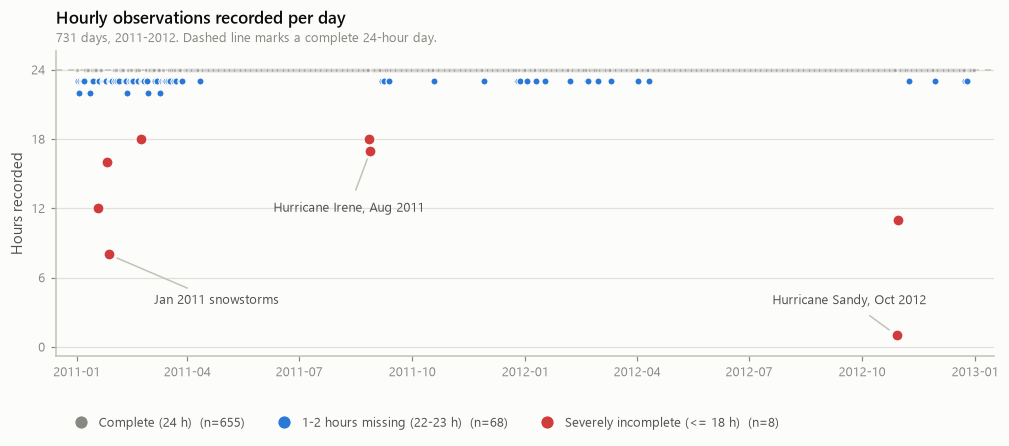

In [16]:
# ---- Figure 1: coverage of every day in the two-year span -----------------
cov = hours_per_day.reset_index()
cov["band"] = pd.cut(cov["observed_hours"], bins=[0, 18, 23, 24],
                     labels=["Severely incomplete (<= 18 h)",
                             "1-2 hours missing (22-23 h)",
                             "Complete (24 h)"])

fig, ax = plt.subplots(figsize=(11, 3.6))

style = {
    "Complete (24 h)":              dict(color=PALETTE["muted"], s=7,  zorder=2, alpha=0.55),
    "1-2 hours missing (22-23 h)":  dict(color=SERIES[0],        s=22, zorder=3),
    "Severely incomplete (<= 18 h)":dict(color=PALETTE["critical"], s=52, zorder=4),
}
handles = []
for band, kw in style.items():
    sub = cov[cov["band"] == band]
    ax.scatter(sub["dteday"], sub["observed_hours"],
               edgecolors=PALETTE["surface"], linewidths=0.8, **kw)
    # Uniform legend markers, so the swatch reads as identity rather than as size.
    handles.append(mpl.lines.Line2D([], [], marker="o", linestyle="none", markersize=7,
                                    color=kw["color"], label=f"{band}  (n={len(sub)})"))

# Selective direct labels: name the three real-world events, not every point.
# Labels sit in the empty lower half of the plot, to the right of the points they mark.
for when, text, xtext, ytext in [
        ("2011-01-27", "Jan 2011 snowstorms",       "2011-03-05",  4.0),
        ("2011-08-28", "Hurricane Irene, Aug 2011", "2011-06-10", 12.0),
        ("2012-10-29", "Hurricane Sandy, Oct 2012", "2012-07-20",  4.0)]:
    t = pd.Timestamp(when)
    ax.annotate(text, xy=(t, cov.loc[cov.dteday == t, "observed_hours"].iloc[0]),
                xytext=(pd.Timestamp(xtext), ytext),
                fontsize=8.2, color=PALETTE["ink2"], ha="left", va="center",
                arrowprops=dict(arrowstyle="-", color=PALETTE["axis"], lw=1,
                                shrinkA=6, shrinkB=6))

ax.set_ylim(-0.8, 25.6)
ax.set_yticks([0, 6, 12, 18, 24])
ax.set_xlim(pd.Timestamp("2010-12-15"), pd.Timestamp("2013-01-16"))
ax.axhline(24, color=PALETTE["axis"], lw=1, ls=(0, (4, 4)), zorder=1)
finish(ax,
       title="Hourly observations recorded per day",
       subtitle="731 days, 2011-2012. Dashed line marks a complete 24-hour day.",
       xlabel=None, ylabel="Hours recorded")
ax.legend(handles=handles, loc="lower left", bbox_to_anchor=(0, -0.28),
          ncol=3, handletextpad=0.4)
save(fig, "fig01_daily_coverage")
plt.show()

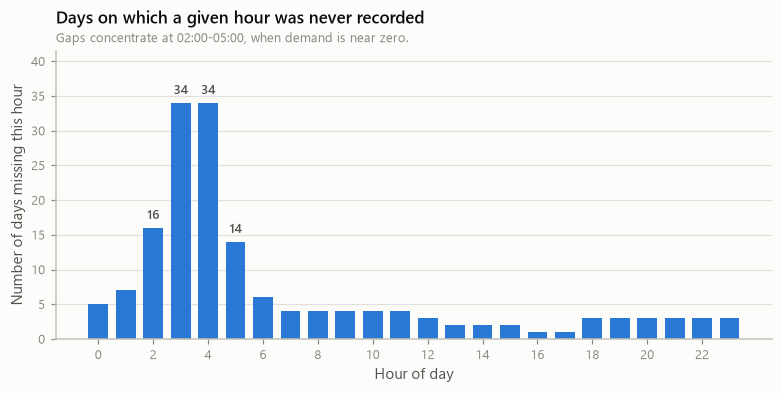

In [17]:
# ---- Figure 2: which hour of the day is missing ---------------------------
fig, ax = plt.subplots(figsize=(8.4, 3.4))

counts = gaps_by_hour.reindex(range(24), fill_value=0)
bars = ax.bar(counts.index, counts.values, width=0.72, color=SERIES[0])

# Direct-label only the notable bars, not every one.
for h in counts[counts >= 10].index:
    ax.text(h, counts[h] + 0.9, str(int(counts[h])), ha="center", va="bottom",
            fontsize=8.2, color=PALETTE["ink2"], fontweight="semibold")

ax.set_xticks(range(0, 24, 2))
ax.set_ylim(0, counts.max() * 1.22)
finish(ax,
       title="Days on which a given hour was never recorded",
       subtitle="Gaps concentrate at 02:00-05:00, when demand is near zero.",
       xlabel="Hour of day", ylabel="Number of days missing this hour")
save(fig, "fig02_missing_by_hour")
plt.show()

> **Finding.** 165 hourly rows out of a possible 17,544 were never written (0.94 %). Their
> distribution is highly informative: **the gaps are overwhelmingly at 02:00–05:00**, the hours when
> demand is near zero. This is the signature of a logging convention in which an hour with **no
> rentals produces no row**, rather than of random data loss. 68 of the 76 incomplete days are
> missing only one or two such night-time hours and remain fully usable.
>
> The remaining 8 days are different in kind and are examined next.

### 1.1.7 Unusual and incomplete days

The eight days with 18 or fewer recorded hours are inspected individually. What matters is not
only *how many* hours are missing but *which* — a random scatter of missing hours suggests a data
fault, whereas a single contiguous block suggests the service itself stopped.

In [18]:
def hour_block_string(hours):
    """Render a day's recorded hours as compact ranges, e.g. '0-2, 5-23'."""
    hs = sorted(hours)
    blocks, start, prev = [], hs[0], hs[0]
    for h in hs[1:]:
        if h != prev + 1:
            blocks.append((start, prev))
            start = h
        prev = h
    blocks.append((start, prev))
    return ", ".join(f"{a:02d}-{b:02d}" if a != b else f"{a:02d}" for a, b in blocks)


INCOMPLETE_THRESHOLD = 20   # days with fewer than this many hours are examined individually
severe = hours_per_day[hours_per_day < INCOMPLETE_THRESHOLD].sort_index()

detail = (df[df["dteday"].isin(severe.index)]
          .groupby("dteday")
          .agg(hours_recorded=("hr", "size"),
               recorded_hours=("hr", hour_block_string),
               total_rentals=("cnt", "sum"),
               worst_weather=("weathersit", "max"),
               mean_temp_C=("temp", lambda s: (s.mean() * 47 - 8).round(1)))
          .reset_index())
detail["weekday"] = detail["dteday"].dt.day_name().str[:3]
detail["n_contiguous_blocks"] = detail["recorded_hours"].str.count(",") + 1
detail = detail[["dteday", "weekday", "hours_recorded", "n_contiguous_blocks",
                 "recorded_hours", "total_rentals", "worst_weather", "mean_temp_C"]]
detail

,dteday,weekday,hours_recorded,n_contiguous_blocks,recorded_hours,total_rentals,worst_weather,mean_temp_C
0,2011-01-18,Tue,12,1,12-23,683,2,2.2000
1,2011-01-26,Wed,16,2,"00-02, 05-17",506,4,2.2000
2,2011-01-27,Thu,8,1,16-23,431,1,1.2000
3,2011-02-22,Tue,18,1,06-23,1450,2,0.6000
4,2011-08-27,Sat,18,1,00-17,1115,3,24.0000
5,2011-08-28,Sun,17,1,07-23,4334,3,25.2000
6,2012-10-29,Mon,1,1,00,22,3,12.7000
7,2012-10-30,Tue,11,1,13-23,1096,3,7.0000


In [19]:
# For context: what does a typical day of each coverage level look like?
ctx = (df.groupby("dteday").agg(hours=("hr", "size"), total=("cnt", "sum"))
         .groupby("hours")["total"].agg(n_days="count", median_rentals="median"))
print("Median daily rentals by number of recorded hours")
print(ctx.to_string())

Median daily rentals by number of recorded hours
       n_days  median_rentals
hours                        
1           1         22.0000
8           1        431.0000
11          1      1,096.0000
12          1        683.0000
16          1        506.0000
17          1      4,334.0000
18          2      1,282.5000
22          6      1,306.0000
23         62      1,857.0000
24        655      4,694.0000


> **Finding — the eight severely incomplete days are real events, not data faults.**
>
> Each one is a **single contiguous block** of recorded hours (or two blocks at most), meaning the
> service was running, stopped, and — where applicable — restarted. Every one coincides with a
> documented Washington D.C. weather emergency:
>
> | Date | Hours | Event |
> |---|---|---|
> | 2011-01-18 | 12–23 only | Overnight snow; morning service suspended |
> | 2011-01-26 | 00–02, 05–17 | The "Commutageddon" snowstorm — the only `weathersit = 4` hour of that winter |
> | 2011-01-27 | 16–23 only | Snowstorm aftermath, late restart |
> | 2011-02-22 | 06–23 only | Overnight winter weather |
> | 2011-08-27 | 00–17 only | **Hurricane Irene** — service shut down as the storm arrived |
> | 2011-08-28 | 07–23 only | Irene aftermath, service resumed mid-morning |
> | 2012-10-29 | **hour 00 only**, 22 rentals | **Hurricane Sandy** — the system closed for the entire day |
> | 2012-10-30 | 13–23 only | Sandy aftermath, afternoon restart |
>
> This distinction matters for the whole assignment. These are **unusual but valid mobility days**,
> not data-quality outliers — exactly the contrast Part 5 Q10 asks about. Deleting them would
> discard the most informative observations in the dataset, and the assignment explicitly forbids
> removing observations to improve clustering scores. They are therefore **kept**, and are expected
> to surface later as DBSCAN noise points.

### 1.1.8 Cleaning actions

Three actions follow from the findings above. Each is stated with its justification, and **no
observation is deleted**.

**Action 1 — Repair the stuck humidity sensor (2011-03-10).**
The 22 zero-humidity readings are replaced by the **mean of the same clock hour on the two
adjacent days**. Repairing is preferred to deleting the day because only one of four weather
fields is affected — temperature, wind speed and all rental counts for that day are sound.

*Why not simple time interpolation?* Because the whole day is missing, the two surviving endpoints
are 2011-03-09 23:00 (`hum` = 0.93) and 2011-03-11 00:00 (`hum` = 1.00) — both **overnight
humidity peaks**. A straight line between them ignores the midday dip and returns a daily mean of
0.97, which would make 2011-03-10 the most humid day in the entire dataset. Same-hour averaging
preserves the diurnal shape and lands the daily mean between its two neighbours, where it belongs.

**Action 2 — Materialise the implicitly missing hours as explicit zero-rental hours.**
The hourly table is re-indexed onto the complete 731 × 24 grid. For the 165 inserted rows the
rental counts are set to **0**, because §1.1.6 established that an unrecorded hour means *no bikes
were rented*, not *the value is unknown*. Weather fields on inserted rows are left as `NaN` so that
daily weather averages are taken over genuinely observed hours only.

*Why this matters:* several required features in §1.2 are **shares** — the morning-peak share is
`rentals 06:00–09:00 ÷ daily total`. On 2011-01-27, where no hour before 16:00 was recorded, the
morning-peak share is genuinely 0 (the service was closed), and the explicit grid makes every
day's denominator the same 24-hour window. Without it, share features would silently mean
different things on different days.

**Action 3 — Attach a data-quality audit column, not a filter.**
`observed_hours` is carried alongside each day so that coverage can be reported and cross-checked
during interpretation. It is a **diagnostic field and is excluded from the clustering feature
set** — it describes the recording process, not mobility behaviour.

In [20]:
# ---- Action 1: repair the stuck humidity sensor ---------------------------
clean = df.copy().sort_values("timestamp")
invalid_hum = clean["hum"] == 0
print(f"Flagging {int(invalid_hum.sum())} zero-humidity readings on "
      f"{clean.loc[invalid_hum, 'dteday'].dt.date.unique()[0]} as invalid.")
clean.loc[invalid_hum, "hum"] = np.nan

# Impute each missing hour with the mean of the SAME HOUR on the days either side.
#
# Interpolating along the time axis instead would be wrong here: an entire day is
# missing, and the two surviving endpoints (2011-03-09 23:00 = 0.93 and
# 2011-03-11 00:00 = 1.00) are both overnight humidity peaks. A straight line between
# them rides that plateau, ignores the midday dip, and returns a daily mean of 0.97 --
# higher than either neighbouring day and the most humid day in the whole dataset.
# Borrowing the same clock hour from the adjacent days preserves the diurnal shape.
# `unstack` is used rather than `pivot_table`, which would silently drop the all-NaN
# 2011-03-10 row and misalign the shifts.
hum_by_dayhour = (clean.set_index(["dteday", "hr"])["hum"].unstack("hr")
                       .reindex(pd.date_range(clean.dteday.min(), clean.dteday.max(), freq="D")))
neighbour_mean = (hum_by_dayhour.shift(1) + hum_by_dayhour.shift(-1)) / 2
neighbour_mean.index.name = "dteday"

clean = clean.join(neighbour_mean.stack().rename("hum_fill"), on=["dteday", "hr"])
n_from_neighbours = int(clean["hum"].isna().sum() - (clean["hum"].isna() & clean["hum_fill"].isna()).sum())
clean["hum"] = clean["hum"].fillna(clean["hum_fill"])

# Fallback for any hour whose neighbours are themselves unrecorded.
n_from_interp = int(clean["hum"].isna().sum())
clean["hum"] = (clean.set_index("timestamp")["hum"]
                     .interpolate(method="time", limit_direction="both").to_numpy())
clean = clean.drop(columns="hum_fill")
print(f"  {n_from_neighbours} repaired from the adjacent days, "
      f"{n_from_interp} by fallback interpolation.")

repaired = clean.loc[clean["dteday"] == "2011-03-10", "hum"]
print(f"\nDaily mean humidity, 2011-03-09 (observed) : "
      f"{clean.loc[clean.dteday == '2011-03-09', 'hum'].mean():.4f}")
print(f"Daily mean humidity, 2011-03-10 (repaired) : {repaired.mean():.4f}")
print(f"Daily mean humidity, 2011-03-11 (observed) : "
      f"{clean.loc[clean.dteday == '2011-03-11', 'hum'].mean():.4f}")
lo = clean.loc[clean.dteday == "2011-03-11", "hum"].mean()
hi = clean.loc[clean.dteday == "2011-03-09", "hum"].mean()
assert lo < repaired.mean() < hi, "humidity repair did not land between its neighbours"
print(f"Repaired value lies between its neighbours : True")
print(f"Remaining hum == 0 rows: {int((clean['hum'] == 0).sum())}")

Flagging 22 zero-humidity readings on 2011-03-10 as invalid.
  22 repaired from the adjacent days, 0 by fallback interpolation.

Daily mean humidity, 2011-03-09 (observed) : 0.7754
Daily mean humidity, 2011-03-10 (repaired) : 0.7084
Daily mean humidity, 2011-03-11 (observed) : 0.6496
Repaired value lies between its neighbours : True
Remaining hum == 0 rows: 0


In [21]:
# ---- Action 2: re-index onto the complete 731 x 24 hourly grid ------------
COUNT_COLS   = ["casual", "registered", "cnt"]
WEATHER_COLS = ["weathersit", "temp", "atemp", "hum", "windspeed"]

all_days = pd.date_range(clean["dteday"].min(), clean["dteday"].max(), freq="D")
full_grid = pd.MultiIndex.from_product([all_days, range(24)], names=["dteday", "hr"])

hourly = (clean.drop(columns=["instant", "timestamp"])
               .set_index(["dteday", "hr"])
               .reindex(full_grid))

# Flag which rows came from the file and which were inserted.
hourly["observed"] = hourly["cnt"].notna()

# Inserted hours had no rentals, by the logging convention established in 1.1.6.
hourly[COUNT_COLS] = hourly[COUNT_COLS].fillna(0).astype(int)

# Day-level calendar attributes are constant within a day, so they are restored from the day itself.
day_attrs = clean.groupby("dteday")[DAY_ATTRS].first()
hourly = hourly.drop(columns=DAY_ATTRS).join(day_attrs, on="dteday")

# Weather on inserted rows stays NaN: it was never measured and must not be invented.
hourly = hourly[DAY_ATTRS + WEATHER_COLS + COUNT_COLS + ["observed"]].sort_index()

print(f"Grid shape          : {hourly.shape[0]:,} rows  (731 x 24 = {731 * 24:,})")
print(f"Rows from the file  : {int(hourly['observed'].sum()):,}")
print(f"Rows inserted as 0  : {int((~hourly['observed']).sum()):,}")
print(f"Rentals added by the fill: {int(hourly.loc[~hourly['observed'], 'cnt'].sum())} "
      f"(zero by construction)")
hourly.head(3)

Grid shape          : 17,544 rows  (731 x 24 = 17,544)
Rows from the file  : 17,379
Rows inserted as 0  : 165
Rentals added by the fill: 0 (zero by construction)


season  yr  mnth  holiday  weekday  workingday  weathersit   temp  atemp    hum  windspeed  casual  registered  cnt  observed
dteday     hr                                                                                                                               
2011-01-01 0        1   0     1        0        6           0      1.0000 0.2400 0.2879 0.8100     0.0000       3          13   16      True
           1        1   0     1        0        6           0      1.0000 0.2200 0.2727 0.8000     0.0000       8          32   40      True
           2        1   0     1        0        6           0      1.0000 0.2200 0.2727 0.8000     0.0000       5          27   32      True

In [22]:
# ---- Action 3: day-level data-quality audit column ------------------------
day_quality = pd.DataFrame({
    "observed_hours": hours_per_day.reindex(all_days).fillna(0).astype(int),
})
day_quality["coverage"] = day_quality["observed_hours"] / 24
day_quality["quality_flag"] = pd.cut(
    day_quality["observed_hours"], bins=[-1, 18, 23, 24],
    labels=["severely_incomplete", "minor_gaps", "complete"])
day_quality.index.name = "dteday"

print(day_quality["quality_flag"].value_counts().rename("n_days").to_string())
print("\nDays flagged 'severely_incomplete' (retained, not deleted):")
print(day_quality.loc[day_quality.quality_flag == "severely_incomplete"].to_string())

quality_flag
complete               655
minor_gaps              68
severely_incomplete      8

Days flagged 'severely_incomplete' (retained, not deleted):
            observed_hours  coverage         quality_flag
dteday                                                   
2011-01-18              12    0.5000  severely_incomplete
2011-01-26              16    0.6667  severely_incomplete
2011-01-27               8    0.3333  severely_incomplete
2011-02-22              18    0.7500  severely_incomplete
2011-08-27              18    0.7500  severely_incomplete
2011-08-28              17    0.7083  severely_incomplete
2012-10-29               1    0.0417  severely_incomplete
2012-10-30              11    0.4583  severely_incomplete


In [23]:
# ---- Verification of the cleaned hourly table -----------------------------
checks = pd.DataFrame([
    ("Rows equal 731 x 24",
     hourly.shape[0] == 731 * 24),
    ("Every (date, hour) present exactly once",
     hourly.index.is_unique and hourly.index.size == 731 * 24),
    ("No missing values in count columns",
     bool(hourly[COUNT_COLS].notna().all().all())),
    ("No missing values in calendar columns",
     bool(hourly[DAY_ATTRS].notna().all().all())),
    ("cnt = casual + registered everywhere",
     bool((hourly["cnt"] == hourly["casual"] + hourly["registered"]).all())),
    ("Total rentals unchanged by cleaning",
     int(hourly["cnt"].sum()) == int(raw["cnt"].sum())),
    ("No zero-humidity readings remain",
     bool((hourly["hum"].dropna() > 0).all())),
    ("Weather NaN only on inserted rows",
     bool(hourly.loc[hourly["observed"], WEATHER_COLS].notna().all().all())),
    ("No observation deleted",
     int(hourly["observed"].sum()) == len(raw)),
], columns=["verification", "passed"])

checks["result"] = np.where(checks["passed"], "PASS", "FAIL")
print(f"Total rentals: raw = {raw['cnt'].sum():,}   cleaned = {int(hourly['cnt'].sum()):,}")
print(f"All checks passed: {bool(checks['passed'].all())}\n")
checks[["verification", "result"]]

Total rentals: raw = 3,292,679   cleaned = 3,292,679
All checks passed: True



,verification,result
0,Rows equal 731 x 24,PASS
1,"Every (date, hour) present exactly once",PASS
2,No missing values in count columns,PASS
3,No missing values in calendar columns,PASS
4,cnt = casual + registered everywhere,PASS
5,Total rentals unchanged by cleaning,PASS
6,No zero-humidity readings remain,PASS
7,Weather NaN only on inserted rows,PASS
8,No observation deleted,PASS


### 1.1.9 Summary of §1.1 decisions

| # | Issue found | Extent | Decision | Justification |
|---|---|---|---|---|
| 1 | Explicit missing values | none | no action | all 17,379 × 17 cells populated |
| 2 | Duplicate records | none | no action | `(dteday, hr)` is a valid primary key |
| 3 | `dteday` stored as text | all rows | converted to `datetime64` | required to aggregate by day |
| 4 | Out-of-domain values | none | no action | every field inside its documented range; `cnt = casual + registered` holds everywhere |
| 5 | `windspeed == 0` | 2,180 rows | **kept** | the variable is binned into 30 levels; 0 is the "calm" bin, not a missing marker |
| 6 | `weathersit == 4` | 3 rows | **kept** | rare but valid severe-weather category |
| 7 | `atemp == 0` | 2 rows | **kept** | physically consistent with −6 °C air temperature and strong wind |
| 8 | `hum == 0` for a whole day (2011-03-10) | 22 rows | **repaired** using the same hour on the adjacent days | 0 % RH is impossible; a stuck sensor. Only one of four weather fields affected, so discarding the day would be disproportionate. Same-hour averaging keeps the diurnal cycle that plain time interpolation would flatten |
| 9 | Implicitly missing hourly rows | 165 rows on 76 days | **inserted with rentals = 0**; weather left `NaN` | gaps cluster at 02:00–05:00 → an hour with no rentals was never logged. Gives every day the same 24-hour denominator for share features |
| 10 | Severely incomplete days | 8 days (≤ 18 h) | **kept**, flagged `severely_incomplete` | contiguous outage blocks matching documented storms (Irene, Sandy, the January 2011 snowstorms) — genuine unusual mobility days, not data errors |

**Nothing was deleted.** All 731 days and all 17,379 original observations survive into §1.2; the
cleaning step only *added* 165 explicit zero rows and repaired 22 sensor readings. The
`quality_flag` column is retained purely as an audit trail and is excluded from the clustering
features.

---
## 1.2 Generate Daily Mobility Features

The cleaned hourly grid is now collapsed to **one feature vector per calendar day** — the unit the
clustering algorithms operate on. Because §1.1 re-indexed the data onto a complete 731 × 24 grid,
every day contributes exactly 24 hourly values, so the aggregations below are computed over an
identical window for every observation and no day is advantaged or penalised by its recording
coverage.

> **Note on units.** Weather features are converted back to **physical units** (°C, %, km/h) using
> the normalisation constants documented in `Readme.txt`. Clustering is unaffected — every feature
> is standardised in §1.3 anyway — but it makes the centroids of §2.1 and the cluster profiles of
> Part 4 directly readable without a second back-transformation step.

In [24]:
# ---- Peak window definitions ----------------------------------------------
# An hourly record labelled `hr = h` covers the interval [h:00, h+1:00). The window
# "06:00 to 09:00" is therefore hours 6, 7 and 8 -- hour 9 covers 09:00-10:00 and lies
# outside it. The same reading gives 16, 17, 18 for the 16:00-19:00 evening window.
MORNING_PEAK = [6, 7, 8]
EVENING_PEAK = [16, 17, 18]
NIGHT_HOURS  = [0, 1, 2, 3, 4, 5]
MIDDAY_HOURS = [11, 12, 13, 14, 15]
OFF_PEAK     = [h for h in range(24) if h not in MORNING_PEAK + EVENING_PEAK]

print(f"Morning peak (06:00-09:00) : hours {MORNING_PEAK}")
print(f"Evening peak (16:00-19:00) : hours {EVENING_PEAK}")
print(f"Off-peak                   : the remaining {len(OFF_PEAK)} hours")

# Normalisation constants from Readme.txt, used to restore physical units.
TEMP_MIN,  TEMP_MAX  = -8, 39     # temp  = (t - t_min) / (t_max - t_min)
ATEMP_MIN, ATEMP_MAX = -16, 50    # atemp = same form, different bounds
WIND_MAX             = 67         # windspeed = ws / 67  (km/h)

Morning peak (06:00-09:00) : hours [6, 7, 8]
Evening peak (16:00-19:00) : hours [16, 17, 18]
Off-peak                   : the remaining 18 hours


In [25]:
# ---- Wide hour-by-day matrices --------------------------------------------
# The cleaned grid is complete, so every day contributes exactly 24 values.
cnt_wide = hourly["cnt"].unstack("hr")
assert cnt_wide.shape == (731, 24), cnt_wide.shape
assert cnt_wide.notna().all().all(), "count grid must be complete"

day_totals = cnt_wide.sum(axis=1)
assert (day_totals > 0).all(), "a share feature would divide by zero"
print(f"Hour-by-day rental matrix: {cnt_wide.shape[0]} days x {cnt_wide.shape[1]} hours")
print(f"Smallest daily total: {int(day_totals.min())} rentals on "
      f"{day_totals.idxmin().date()} (Hurricane Sandy)")

Hour-by-day rental matrix: 731 days x 24 hours
Smallest daily total: 22 rentals on 2012-10-29 (Hurricane Sandy)


In [26]:
# ---- Build the daily feature vector ---------------------------------------
g   = hourly.groupby(level="dteday")
obs = hourly[hourly["observed"]].groupby(level="dteday")   # weather: measured hours only

daily = pd.DataFrame(index=cnt_wide.index)
daily.index.name = "dteday"

# --- Volume: how much demand, and how peaked -------------------------------
daily["total_rentals"]       = day_totals
daily["mean_hourly_rentals"] = cnt_wide.mean(axis=1)
daily["max_hourly_rentals"]  = cnt_wide.max(axis=1)
# ddof=0: the 24 hours are the complete population of the day, not a sample from it.
daily["std_hourly_rentals"]  = cnt_wide.std(axis=1, ddof=0)

# --- Temporal shape: when during the day demand occurs ---------------------
daily["morning_peak_share"] = cnt_wide[MORNING_PEAK].sum(axis=1) / day_totals
daily["evening_peak_share"] = cnt_wide[EVENING_PEAK].sum(axis=1) / day_totals
daily["offpeak_share"]      = cnt_wide[OFF_PEAK].sum(axis=1)     / day_totals
daily["night_share"]        = cnt_wide[NIGHT_HOURS].sum(axis=1)  / day_totals
daily["midday_share"]       = cnt_wide[MIDDAY_HOURS].sum(axis=1) / day_totals

# Peakedness, scale-free: how tall the busiest hour is relative to a flat day.
daily["peak_to_mean_ratio"] = daily["max_hourly_rentals"] / daily["mean_hourly_rentals"]

# Shannon entropy of the 24-hour demand profile, normalised to [0, 1].
# 1.0 = demand spread evenly across the day; low = concentrated in a few hours.
p = cnt_wide.div(day_totals, axis=0)
# "+ 0.0" normalises the negative zero that a single-active-hour day produces.
daily["hourly_entropy"] = (-(p * np.log(p.where(p > 0))).sum(axis=1) / np.log(24)).clip(0, 1) + 0.0

# --- User mix --------------------------------------------------------------
daily["casual_proportion"]     = g["casual"].sum()     / day_totals
daily["registered_proportion"] = g["registered"].sum() / day_totals

# --- Weather, restored to physical units -----------------------------------
daily["avg_temp_C"]         = g["temp"].mean()  * (TEMP_MAX - TEMP_MIN) + TEMP_MIN
daily["avg_feels_temp_C"]   = g["atemp"].mean() * (ATEMP_MAX - ATEMP_MIN) + ATEMP_MIN
daily["avg_humidity_pct"]   = g["hum"].mean() * 100
daily["avg_windspeed_kmh"]  = g["windspeed"].mean() * WIND_MAX
daily["temp_range_C"]       = (g["temp"].max() - g["temp"].min()) * (TEMP_MAX - TEMP_MIN)
daily["bad_weather_share"]  = obs["weathersit"].apply(lambda s: (s >= 3).mean())

print(f"Daily feature matrix: {daily.shape[0]} days x {daily.shape[1]} candidate features")
daily.head()

Daily feature matrix: 731 days x 19 candidate features


,total_rentals,mean_hourly_rentals,max_hourly_rentals,std_hourly_rentals,morning_peak_share,evening_peak_share,offpeak_share,night_share,midday_share,peak_to_mean_ratio,hourly_entropy,casual_proportion,registered_proportion,avg_temp_C,avg_feels_temp_C,avg_humidity_pct,avg_windspeed_kmh,temp_range_C,bad_weather_share
dteday,,,,,,,,,,,,,,,,,,,
2011-01-01,985,41.0417,110,33.5702,0.0132,0.1980,0.7888,0.1046,0.4569,2.6802,0.8892,0.3360,0.6640,8.1758,7.9993,80.5833,10.7499,12.2200,0.0833
2011-01-02,801,33.3750,93,29.3539,0.0137,0.2422,0.7441,0.0649,0.4632,2.7865,0.8686,0.1635,0.8365,9.0835,7.3468,69.6087,16.6521,11.2800,0.2174
2011-01-03,1349,56.2083,157,48.6861,0.1838,0.2891,0.5271,0.0082,0.2387,2.7932,0.8692,0.0890,0.9110,1.2291,-3.4993,43.7273,16.6367,5.6400,0.0000
2011-01-04,1562,65.0833,212,58.9243,0.1978,0.3054,0.4968,0.0090,0.2305,3.2574,0.8645,0.0691,0.9309,1.4000,-2.0000,59.0435,10.7398,8.4600,0.0000
2011-01-05,1600,66.6667,195,57.6416,0.1975,0.2800,0.5225,0.0119,0.2000,2.9250,0.8742,0.0512,0.9487,2.6670,-0.8682,43.6957,12.5223,6.5800,0.0000


In [27]:
# ---- Context table: labels for interpretation, NEVER for clustering -------
SEASON_NAME  = {1: "Winter", 2: "Spring", 3: "Summer", 4: "Fall"}
WEATHER_NAME = {1: "Clear", 2: "Mist", 3: "Light precip.", 4: "Heavy precip."}

context = g[DAY_ATTRS].first()
context["day_name"]     = context.index.day_name()
context["is_weekend"]   = context["weekday"].isin([0, 6]).astype(int)
context["season_name"]  = context["season"].map(SEASON_NAME)
context["weather_mode"] = obs["weathersit"].agg(lambda s: int(s.mode().iloc[0]))
context["weather_name"] = context["weather_mode"].map(WEATHER_NAME)
context["date"]         = context.index
context = context.join(day_quality)

print(f"Context table: {context.shape[0]} days x {context.shape[1]} descriptive columns")
print("\nThese columns describe each day but are EXCLUDED from the clustering input:")
print(", ".join(context.columns))
context.head()

Context table: 731 days x 15 descriptive columns

These columns describe each day but are EXCLUDED from the clustering input:
season, yr, mnth, holiday, weekday, workingday, day_name, is_weekend, season_name, weather_mode, weather_name, date, observed_hours, coverage, quality_flag


,season,yr,mnth,holiday,weekday,workingday,day_name,is_weekend,season_name,weather_mode,weather_name,date,observed_hours,coverage,quality_flag
dteday,,,,,,,,,,,,,,,
2011-01-01,1,0,1,0,6,0,Saturday,1,Winter,1,Clear,2011-01-01,24,1.0000,complete
2011-01-02,1,0,1,0,0,0,Sunday,1,Winter,2,Mist,2011-01-02,23,0.9583,minor_gaps
2011-01-03,1,0,1,0,1,1,Monday,0,Winter,1,Clear,2011-01-03,22,0.9167,minor_gaps
2011-01-04,1,0,1,0,2,1,Tuesday,0,Winter,1,Clear,2011-01-04,23,0.9583,minor_gaps
2011-01-05,1,0,1,0,3,1,Wednesday,0,Winter,1,Clear,2011-01-05,23,0.9583,minor_gaps


### 1.2.1 The candidate feature set

Nineteen features were constructed, grouped by the aspect of mobility they describe. All twelve
features required by the specification are present; the seven additions are marked.

The **clustering unit is the day**, so the frame carries one row per day and the date survives only
as the index. In line with the restrictions, the clustering matrix contains **no date identifier**
(`dteday`, `mnth`, `yr`, `weekday`) and **no calendar attribute** (`season`, `holiday`,
`workingday`). Those live in the separate `context` table and are used only to *validate and
interpret* clusters in Part 4 — never to form them. This matters: if `workingday` were a feature,
any commuting-versus-leisure split the clustering discovered would be a restatement of an input
rather than a finding.

Deliberate redundancy is retained at this stage. The three temporal shares sum to 1 by
construction, and the two user proportions sum to 1 exactly, so each pair contains one strictly
superfluous column. Both are required by the specification and both are therefore built here;
identifying and removing the redundancy is the task of the correlation analysis in §1.3.

In [28]:
FEATURE_DOC = pd.DataFrame([
    ("total_rentals",         "Volume",   "Required", "Sum of hourly rentals over the day"),
    ("mean_hourly_rentals",   "Volume",   "Required", "Mean rentals per hour (total / 24)"),
    ("max_hourly_rentals",    "Volume",   "Required", "Busiest single hour"),
    ("std_hourly_rentals",    "Volume",   "Required", "Std. dev. of the 24 hourly counts (ddof=0)"),
    ("morning_peak_share",    "Shape",    "Required", "Share of rentals in hours 6-8"),
    ("evening_peak_share",    "Shape",    "Required", "Share of rentals in hours 16-18"),
    ("offpeak_share",         "Shape",    "Required", "Share outside both peak windows"),
    ("night_share",           "Shape",    "Added",    "Share in hours 0-5: night-time activity"),
    ("midday_share",          "Shape",    "Added",    "Share in hours 11-15: leisure signature"),
    ("peak_to_mean_ratio",    "Shape",    "Added",    "Busiest hour / mean hour: scale-free peakedness"),
    ("hourly_entropy",        "Shape",    "Added",    "Normalised entropy of the 24-hour profile; 1 = flat"),
    ("casual_proportion",     "User mix", "Required", "Casual rentals / total"),
    ("registered_proportion", "User mix", "Required", "Registered rentals / total"),
    ("avg_temp_C",            "Weather",  "Required", "Mean air temperature, degrees C"),
    ("avg_humidity_pct",      "Weather",  "Required", "Mean relative humidity, %"),
    ("avg_windspeed_kmh",     "Weather",  "Required", "Mean wind speed, km/h"),
    ("avg_feels_temp_C",      "Weather",  "Added",    "Mean apparent temperature, degrees C"),
    ("temp_range_C",          "Weather",  "Added",    "Daily temperature range (max - min)"),
    ("bad_weather_share",     "Weather",  "Added",    "Share of observed hours with weathersit >= 3"),
], columns=["feature", "group", "status", "description"])

assert set(FEATURE_DOC["feature"]) == set(daily.columns), "documentation is out of sync"
daily = daily[FEATURE_DOC["feature"].tolist()]   # documentation defines the canonical order

print(f"{(FEATURE_DOC['status'] == 'Required').sum()} required + "
      f"{(FEATURE_DOC['status'] == 'Added').sum()} added = {len(FEATURE_DOC)} candidate features")
FEATURE_DOC

12 required + 7 added = 19 candidate features


,feature,group,status,description
0,total_rentals,Volume,Required,Sum of hourly rentals over the day
1,mean_hourly_rentals,Volume,Required,Mean rentals per hour (total / 24)
2,max_hourly_rentals,Volume,Required,Busiest single hour
3,std_hourly_rentals,Volume,Required,Std. dev. of the 24 hourly counts (ddof=0)
4,morning_peak_share,Shape,Required,Share of rentals in hours 6-8
5,evening_peak_share,Shape,Required,Share of rentals in hours 16-18
6,offpeak_share,Shape,Required,Share outside both peak windows
7,night_share,Shape,Added,Share in hours 0-5: night-time activity
8,midday_share,Shape,Added,Share in hours 11-15: leisure signature
9,peak_to_mean_ratio,Shape,Added,Busiest hour / mean hour: scale-free peakedness


### 1.2.2 Why these seven additions

Each added feature captures an aspect of mobility that the required twelve cannot express.

- **`night_share`** (00:00–05:00) separates late-night activity from ordinary daytime off-peak
  demand. The required `offpeak_share` lumps a 03:00 rental together with a 13:00 one, yet the two
  describe entirely different behaviour.
- **`midday_share`** (11:00–15:00) is the positive signature of leisure riding. Where a commuting
  day is bimodal, a leisure day carries a single broad midday hump — invisible to `offpeak_share`,
  which would report a similar value for both.
- **`peak_to_mean_ratio`** measures peakedness independently of volume. `std_hourly_rentals`
  conflates the two: a busy flat day and a quiet spiky day can share a standard deviation.
- **`hourly_entropy`** summarises the *whole* 24-hour profile in one number rather than through
  fixed windows, and is scale-free. It is the cleanest single discriminator between concentrated
  commuting demand and evenly spread recreational demand.
- **`avg_feels_temp_C`** is what riders actually experience; wind chill and humidity can separate
  it sharply from air temperature. It is expected to correlate strongly with `avg_temp_C` and is a
  candidate for removal in §1.3 — it is included so that the decision is made on evidence.
- **`temp_range_C`** distinguishes stable overcast days from clear days with a large diurnal swing,
  which affects when during the day riding is comfortable.
- **`bad_weather_share`** converts the ordinal `weathersit` code into a continuous daily severity
  measure, capturing a two-hour thunderstorm that barely moves the daily humidity average.

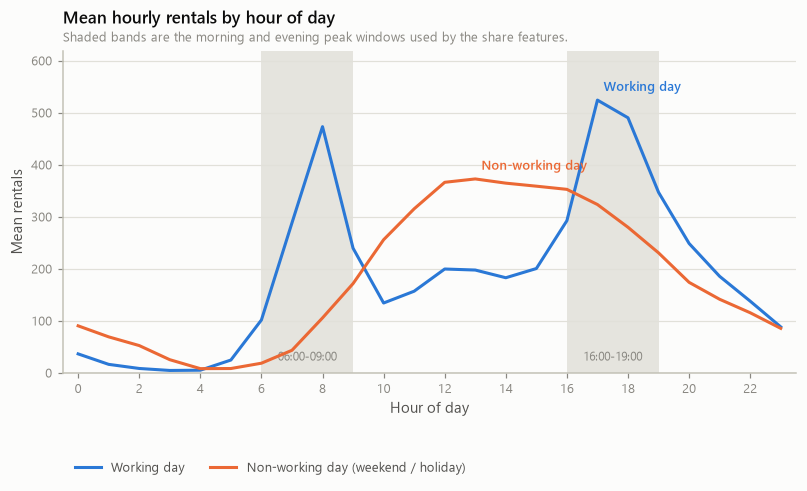

In [29]:
# ---- Figure 3: the profile that justifies the peak windows ---------------
profile = (hourly.join(context["workingday"].rename("wd"), on="dteday")
                 .groupby([ "wd", hourly.index.get_level_values("hr")])["cnt"].mean()
                 .unstack("wd"))
profile.columns = ["Non-working day (weekend / holiday)", "Working day"]

fig, ax = plt.subplots(figsize=(8.6, 3.8))

for window, label in [(MORNING_PEAK, "06:00-09:00"), (EVENING_PEAK, "16:00-19:00")]:
    ax.axvspan(window[0], window[-1] + 1, color=PALETTE["grid"], alpha=0.85, zorder=0)
    # Axes-fraction y keeps the caption pinned inside the band regardless of autoscaling.
    ax.text(window[0] + 1.5, 0.03, label, transform=ax.get_xaxis_transform(),
            ha="center", va="bottom", fontsize=8, color=PALETTE["muted"])

for col, colour in zip(["Working day", "Non-working day (weekend / holiday)"], SERIES[:2]):
    ax.plot(profile.index, profile[col], color=colour, label=col, zorder=3)
    # Direct label at the line's own maximum, so identity never rests on colour alone.
    h = profile[col].idxmax()
    ax.annotate(col.split(" (")[0], xy=(h, profile[col].loc[h]),
                xytext=(4, 6), textcoords="offset points",
                fontsize=8.5, color=colour, fontweight="semibold")

ax.set_xticks(range(0, 24, 2))
ax.set_xlim(-0.5, 23.5)
ax.set_ylim(0, profile.to_numpy().max() * 1.18)
finish(ax,
       title="Mean hourly rentals by hour of day",
       subtitle="Shaded bands are the morning and evening peak windows used by the share features.",
       xlabel="Hour of day", ylabel="Mean rentals")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.24), ncol=2)
save(fig, "fig03_hourly_profile")
plt.show()

> **Reading.** The two profiles are qualitatively different, which is the premise the whole
> analysis rests on. Working days are **sharply bimodal**, with a narrow commuting spike at 08:00
> and a larger one at 17:00–18:00 — both falling squarely inside the specified peak windows, which
> confirms that the 06:00–09:00 and 16:00–19:00 definitions capture the intended behaviour.
> Non-working days show **no morning peak at all**, instead rising to a single broad plateau
> between 11:00 and 16:00. This is exactly the contrast that `morning_peak_share`, `midday_share`
> and `hourly_entropy` are designed to encode, and it is a strong prior that at least one
> commuting/leisure split exists in the data before any clustering is run.

### 1.2.3 Verification of the daily features

The construction is checked against the identities it must satisfy by definition, and against the
raw file totals.

In [30]:
share_sum = (daily["morning_peak_share"] + daily["evening_peak_share"] + daily["offpeak_share"])
user_sum  = (daily["casual_proportion"] + daily["registered_proportion"])

feature_checks = pd.DataFrame([
    ("One row per calendar day (731)",
     len(daily) == 731 and daily.index.is_unique),
    ("No missing values in any feature",
     bool(daily.notna().all().all())),
    ("No infinite values",
     bool(np.isfinite(daily.to_numpy()).all())),
    ("Sum of daily totals equals the raw file",
     int(daily["total_rentals"].sum()) == int(raw["cnt"].sum())),
    ("mean_hourly_rentals == total / 24",
     np.allclose(daily["mean_hourly_rentals"], daily["total_rentals"] / 24)),
    ("morning + evening + offpeak shares == 1",
     np.allclose(share_sum, 1.0)),
    ("casual + registered proportions == 1",
     np.allclose(user_sum, 1.0)),
    ("All shares within [0, 1]",
     bool(daily.filter(like="share").ge(0).all().all()
          and daily.filter(like="share").le(1).all().all())),
    ("Entropy within [0, 1]",
     bool(daily["hourly_entropy"].between(0, 1).all())),
    ("max_hourly >= mean_hourly for every day",
     bool((daily["max_hourly_rentals"] >= daily["mean_hourly_rentals"]).all())),
    ("No date identifier or calendar attribute among the features",
     not set(daily.columns) & {"dteday", "date", "yr", "mnth", "weekday",
                               "season", "holiday", "workingday", "observed_hours"}),
], columns=["verification", "passed"])

feature_checks["result"] = np.where(feature_checks["passed"], "PASS", "FAIL")
assert feature_checks["passed"].all(), "daily feature construction failed a check"
print(f"All {len(feature_checks)} checks passed.\n")
feature_checks[["verification", "result"]]

All 11 checks passed.



,verification,result
0,One row per calendar day (731),PASS
1,No missing values in any feature,PASS
2,No infinite values,PASS
3,Sum of daily totals equals the raw file,PASS
4,mean_hourly_rentals == total / 24,PASS
5,morning + evening + offpeak shares == 1,PASS
6,casual + registered proportions == 1,PASS
7,"All shares within [0, 1]",PASS
8,"Entropy within [0, 1]",PASS
9,max_hourly >= mean_hourly for every day,PASS


In [31]:
# Summary statistics of the candidate feature set, in original (non-standardised) units.
summary = daily.describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
summary.insert(0, "group", FEATURE_DOC.set_index("feature")["group"])
summary.round(3)

,group,mean,std,min,25%,50%,75%,max
total_rentals,Volume,"4,504.3490","1,937.2110",22.0000,"3,152.0000","4,548.0000","5,956.0000","8,714.0000"
mean_hourly_rentals,Volume,187.6810,80.7170,0.9170,131.3330,189.5000,248.1670,363.0830
max_hourly_rentals,Volume,510.2910,214.6260,22.0000,356.0000,509.0000,659.0000,977.0000
std_hourly_rentals,Volume,150.0280,62.5710,4.3960,108.0790,150.1480,197.0870,275.9800
morning_peak_share,Shape,0.1420,0.0790,0.0000,0.0430,0.1750,0.1980,0.3810
evening_peak_share,Shape,0.2610,0.0500,0.0000,0.2310,0.2730,0.2960,0.4920
offpeak_share,Shape,0.5970,0.1090,0.4020,0.5140,0.5430,0.7270,1.0000
night_share,Shape,0.0350,0.0450,0.0000,0.0180,0.0230,0.0470,1.0000
midday_share,Shape,0.2710,0.1100,0.0000,0.1910,0.2170,0.3830,0.5470
peak_to_mean_ratio,Shape,2.8100,0.9160,1.7880,2.4850,2.8140,3.0050,24.0000


In [32]:
# Sanity check against known behaviour: do the features separate the days we already understand?
probe = daily.join(context[["day_name", "workingday", "quality_flag"]])
cols = ["total_rentals", "morning_peak_share", "evening_peak_share",
        "midday_share", "casual_proportion", "hourly_entropy"]

print("Mean feature values by working day vs non-working day")
print(probe.groupby("workingday")[cols].mean().round(3).to_string())

print("\nThe three most extreme days on the entropy scale, with context:")
extreme = pd.concat([probe.nsmallest(2, "hourly_entropy"), probe.nlargest(1, "hourly_entropy")])
print(extreme[cols + ["day_name", "quality_flag"]].round(3).to_string())

Mean feature values by working day vs non-working day
            total_rentals  morning_peak_share  evening_peak_share  midday_share  casual_proportion  hourly_entropy
workingday                                                                                                        
0              4,330.1690              0.0380              0.2170        0.4150             0.2910          0.8960
1              4,584.8200              0.1890              0.2820        0.2050             0.1230          0.8830

The three most extreme days on the entropy scale, with context:
            total_rentals  morning_peak_share  evening_peak_share  midday_share  casual_proportion  hourly_entropy  day_name         quality_flag
dteday                                                                                                                                           
2012-10-29             22              0.0000              0.0000        0.0000             0.0910          0.0000    Monday  sev

> **Reading.** The features behave as intended. Working days average a morning-peak share of
> roughly three times that of non-working days and a much lower casual proportion, while
> non-working days carry a far larger midday share — a split the clustering algorithms should
> recover *without* ever seeing the `workingday` flag.
>
> The entropy extremes are also informative: the least even profiles belong to the storm days
> identified in §1.1.7, where almost all of a small daily total falls into a handful of hours.
> Those days now hold valid, fully-defined feature vectors rather than missing ones, and will be
> carried into the clustering as legitimate observations.

### 1.2.4 Output of §1.2

Two aligned tables are carried forward, both indexed by date:

| Table | Shape | Role |
|---|---|---|
| `daily` | 731 × 19 | Candidate clustering features, original units. Pruned and scaled in §1.3. |
| `context` | 731 × 13 | Calendar, weather and data-quality labels. Used **only** for interpretation in Part 4. |

Keeping the two strictly separate is what allows Part 4 to test the discovered clusters against
weekday, season, holiday and weather distributions as genuinely *external* validation.

In [33]:
CANDIDATE_FEATURES = list(daily.columns)
print(f"daily   : {daily.shape[0]} x {daily.shape[1]}   (clustering candidates)")
print(f"context : {context.shape[0]} x {context.shape[1]}   (interpretation only)")
print(f"Index aligned: {daily.index.equals(context.index)}")
print(f"\nCarried into 1.3 as CANDIDATE_FEATURES:\n  " +
      "\n  ".join(f"{i:>2}. {c}" for i, c in enumerate(CANDIDATE_FEATURES, 1)))

daily   : 731 x 19   (clustering candidates)
context : 731 x 15   (interpretation only)
Index aligned: True

Carried into 1.3 as CANDIDATE_FEATURES:
   1. total_rentals
   2. mean_hourly_rentals
   3. max_hourly_rentals
   4. std_hourly_rentals
   5. morning_peak_share
   6. evening_peak_share
   7. offpeak_share
   8. night_share
   9. midday_share
  10. peak_to_mean_ratio
  11. hourly_entropy
  12. casual_proportion
  13. registered_proportion
  14. avg_temp_C
  15. avg_humidity_pct
  16. avg_windspeed_kmh
  17. avg_feels_temp_C
  18. temp_range_C
  19. bad_weather_share


---
## 1.3 Prepare the Clustering Data

The 19 candidate features are now reduced to a clustering matrix. Four stages are applied in the
order the specification lists them, each with an explicit, pre-declared decision rule so that no
choice is made by inspection of the clustering results:

| Stage | Question | Rule |
|---|---|---|
| §1.3.1 | How is each feature distributed? | Skewness and kurtosis, decomposed by data-quality flag |
| §1.3.2 | Which are skewed enough to transform? | Transform if \|skew\| > 0.75 **and** the transform actually reduces it |
| §1.3.3 | Which are redundant? | Remove algebraic identities, then prune \|r\| until every VIF < 5 |
| §1.3.5 | How are features put on a common scale? | Z-score standardisation |

Nothing here removes an *observation*; only features are removed. All 731 days survive into Part 2.

### 1.3.1 Feature distribution analysis

Skewness and kurtosis are reported twice: over all 731 days, and again excluding the eight
`severely_incomplete` storm days identified in §1.1.7. The comparison distinguishes a feature whose
*bulk distribution* is genuinely asymmetric from one that merely has a few extreme days attached —
a distinction that determines whether a transformation is appropriate at all.

In [34]:
from scipy import stats

storm_mask = (context["quality_flag"] == "severely_incomplete")
print(f"Storm days excluded from the second column: {int(storm_mask.sum())}")

skew_report = pd.DataFrame({
    "skew_all":        daily.skew(),
    "skew_excl_storm": daily[~storm_mask].skew(),
    "kurt_all":        daily.kurtosis(),
    "kurt_excl_storm": daily[~storm_mask].kurtosis(),
    "n_zeros":         (daily == 0).sum(),
})

SKEW_LIMIT = 0.75   # conventional threshold for "moderately skewed"

def classify(r):
    """The storm-excluded value decides, since it describes the bulk distribution."""
    if abs(r.skew_excl_storm) > SKEW_LIMIT:
        return "genuinely skewed"
    if abs(r.skew_all) > SKEW_LIMIT:
        return "storm-driven"
    return "symmetric"

skew_report["verdict"] = skew_report.apply(classify, axis=1)
skew_report = skew_report.reindex(skew_report.skew_all.abs().sort_values(ascending=False).index)
print(skew_report["verdict"].value_counts().to_string())
skew_report.round(3)

Storm days excluded from the second column: 8
verdict
symmetric           12
genuinely skewed     5
storm-driven         2


,skew_all,skew_excl_storm,kurt_all,kurt_excl_storm,n_zeros,verdict
peak_to_mean_ratio,17.1240,0.7180,393.0210,2.8470,0,storm-driven
hourly_entropy,-16.1570,-0.1640,348.6670,1.0860,1,storm-driven
night_share,14.3290,2.9880,293.0960,19.0810,5,genuinely skewed
bad_weather_share,2.6240,2.5410,7.7640,7.1240,431,genuinely skewed
registered_proportion,-0.9390,-0.9410,0.0880,0.0900,0,genuinely skewed
casual_proportion,0.9390,0.9410,0.0880,0.0900,0,genuinely skewed
evening_peak_share,-0.7410,-0.7720,2.6540,0.8800,1,genuinely skewed
offpeak_share,0.6960,0.6610,-0.9650,-1.1530,0,symmetric
avg_windspeed_kmh,0.6770,0.6820,0.4110,0.4570,0,symmetric
midday_share,0.6560,0.7000,-0.8790,-0.9260,2,symmetric


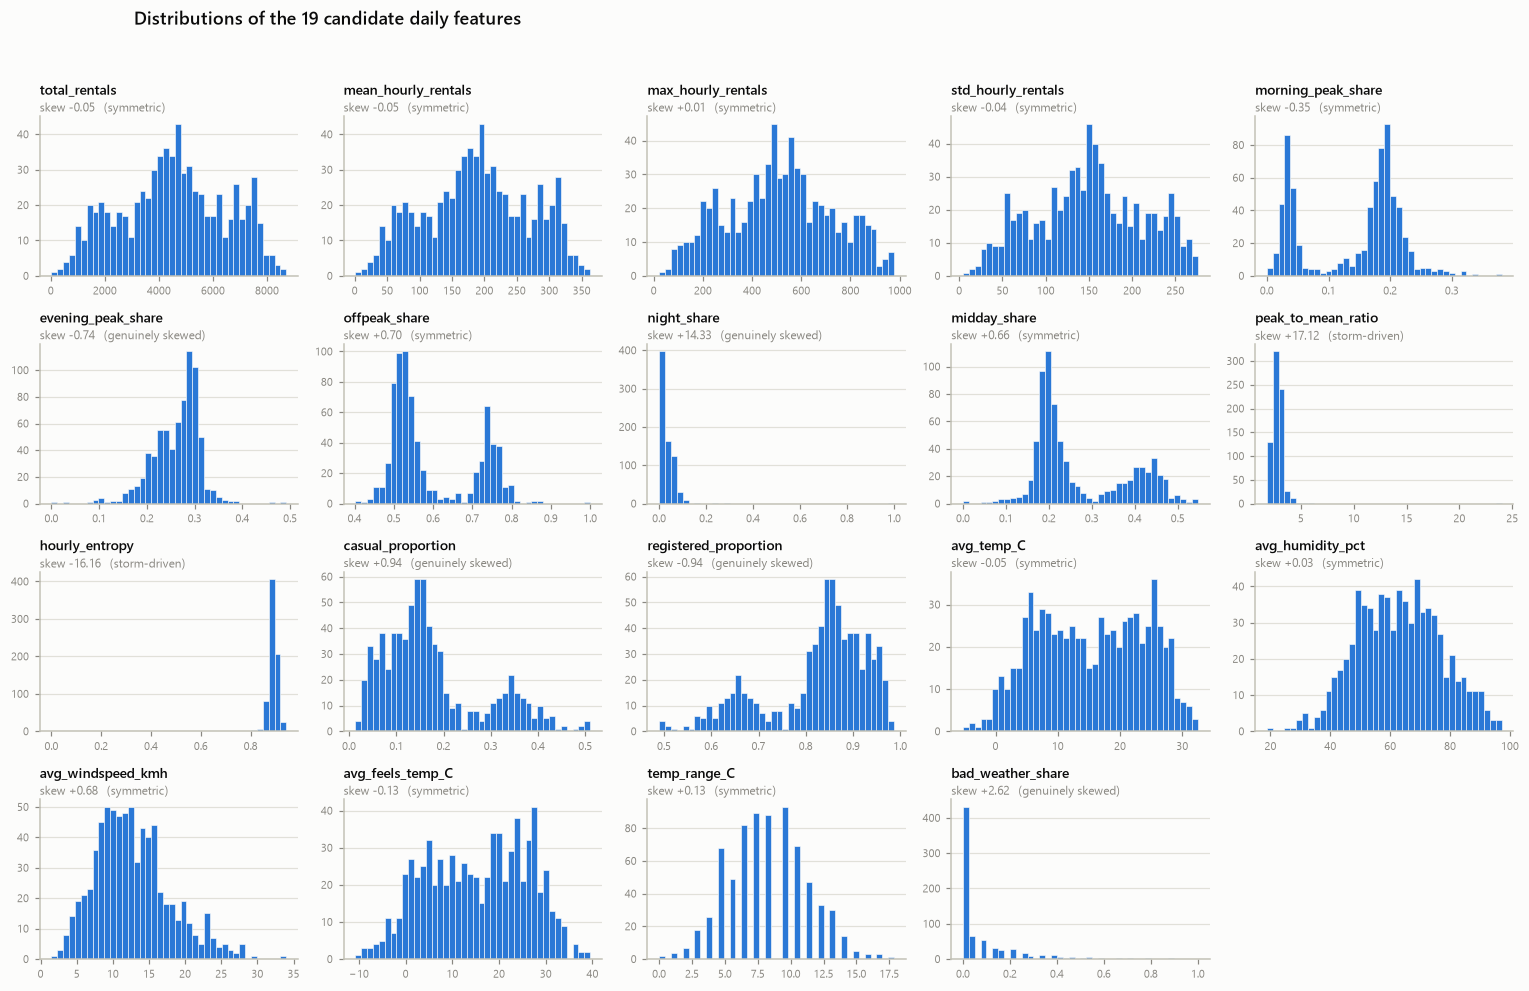

In [35]:
# ---- Figure 4: distribution of every candidate feature ---------------------
order = FEATURE_DOC["feature"].tolist()
fig, axes = plt.subplots(4, 5, figsize=(14, 9))

for ax, col in zip(axes.flat, order):
    v = skew_report.loc[col]
    ax.hist(daily[col], bins=40, color=SERIES[0], edgecolor=PALETTE["surface"], linewidth=0.4)
    ax.set_title(col, fontsize=9, pad=14)
    ax.text(0, 1.01, f"skew {v.skew_all:+.2f}   ({v.verdict})",
            transform=ax.transAxes, fontsize=7.6, color=PALETTE["muted"], va="bottom")
    ax.tick_params(labelsize=7)
    ax.set_ylabel("")
    ax.xaxis.grid(False); ax.yaxis.grid(True)

for ax in axes.flat[len(order):]:
    ax.set_visible(False)

fig.suptitle("Distributions of the 19 candidate daily features", x=0.09, y=0.995,
             ha="left", fontsize=12, fontweight="semibold", color=PALETTE["ink"])
fig.tight_layout(rect=[0, 0, 1, 0.97])
save(fig, "fig04_feature_histograms")
plt.show()

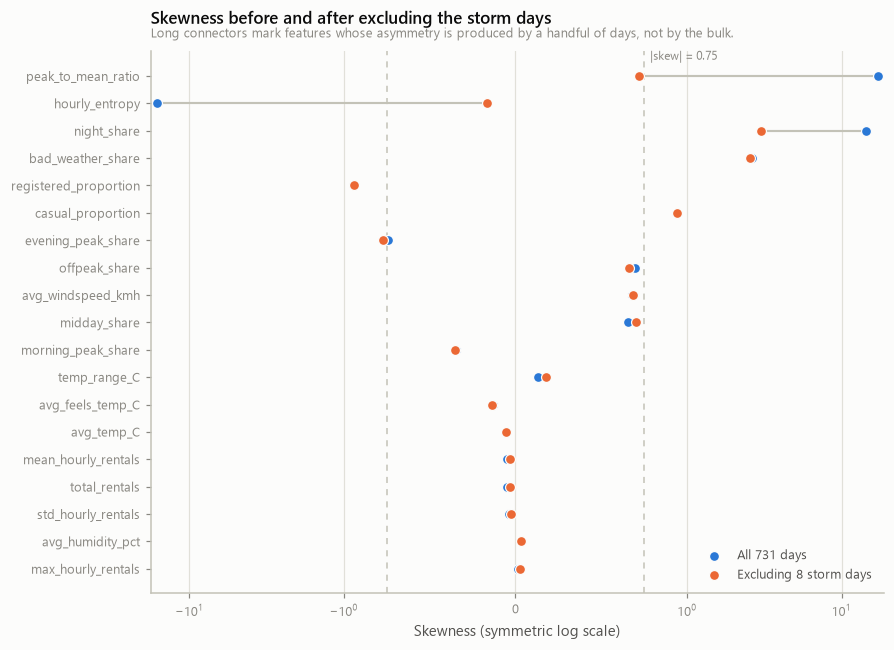

In [36]:
# ---- Figure 5: is the skew real, or is it the eight storm days? -----------
sk = skew_report.loc[skew_report.skew_all.abs().sort_values().index]
y = np.arange(len(sk))

fig, ax = plt.subplots(figsize=(8.6, 6.4))
ax.hlines(y, sk.skew_all, sk.skew_excl_storm, color=PALETTE["axis"], lw=1.4, zorder=1)
ax.scatter(sk.skew_all, y, s=42, color=SERIES[0], label="All 731 days",
           edgecolors=PALETTE["surface"], linewidths=0.8, zorder=3)
ax.scatter(sk.skew_excl_storm, y, s=42, color=SERIES[1], label="Excluding 8 storm days",
           edgecolors=PALETTE["surface"], linewidths=0.8, zorder=3)

for x in (-SKEW_LIMIT, SKEW_LIMIT):
    ax.axvline(x, color=PALETTE["axis"], lw=1, ls=(0, (4, 4)), zorder=0)
ax.text(SKEW_LIMIT, len(sk) - 0.3, "  |skew| = 0.75", fontsize=8, color=PALETTE["muted"], va="center")

ax.set_yticks(y); ax.set_yticklabels(sk.index, fontsize=8.5)
ax.set_xscale("symlog", linthresh=1)
ax.yaxis.grid(False); ax.xaxis.grid(True)
finish(ax, title="Skewness before and after excluding the storm days",
       subtitle="Long connectors mark features whose asymmetry is produced by a handful of days, not by the bulk.",
       xlabel="Skewness (symmetric log scale)", ylabel=None, ygrid_only=False)
ax.legend(loc="lower right")
save(fig, "fig05_skew_decomposition")
plt.show()

> **Finding — most of the extreme skew is not a distributional property at all.**
>
> Three features report enormous skewness over the full sample: `peak_to_mean_ratio` (+17.1),
> `hourly_entropy` (−16.2) and `night_share` (+14.3), with kurtosis values up to 393. Removing just
> eight days collapses the first two almost completely — `peak_to_mean_ratio` falls to +0.72 and
> `hourly_entropy` to −0.16, with kurtosis dropping from 393 to 2.8. Their bulk distributions are
> effectively symmetric; the apparent skew is entirely the storm days, where nearly all of a very
> small daily total falls into one or two hours.
>
> This matters for the transformation decision. A power transform strong enough to "fix" a skew of
> 17 would compress precisely the eight observations that are most informative — the genuine
> extreme-mobility days that DBSCAN is expected to isolate as noise in §2.3. **Storm-driven skew is
> therefore left untransformed by design.** Only features that remain skewed *after* the storm days
> are set aside are treated as genuinely skewed: `night_share` (+2.99), `bad_weather_share` (+2.54),
> `casual_proportion` (+0.94) and its mirror `registered_proportion` (−0.94), and marginally
> `evening_peak_share` (−0.77).

### 1.3.2 Transformations

**Rule.** A feature is transformed if its storm-excluded \|skew\| exceeds 0.75 **and** the candidate
transform actually reduces \|skew\|. The second clause prevents a transform being applied
mechanically where it does not help.

**Transform chosen: cube root.** It is monotone, defined at zero and for negative values, and needs
no fitted parameter, so it can be reported exactly and reversed trivially.

*Why not Yeo-Johnson?* It was tried and fits better on paper — `night_share` reaches a skew of 0.50
against 1.00 for the cube root. But the fitted exponent is **λ = −28.8**, which saturates the upper
tail so severely that a moderately night-heavy day and the Hurricane Sandy day (`night_share` = 1.0)
map to almost the same value. That destroys exactly the structure §2.3 is meant to detect, and it
buys nothing: the two transforms produce an **identical final feature set** (§1.3.3). The gentler,
parameter-free option is therefore preferred.

In [37]:
skewed_candidates = skew_report.index[skew_report["verdict"] == "genuinely skewed"].tolist()
print("Candidates (storm-excluded |skew| > 0.75):", skewed_candidates)

# Apply the candidate transform and keep it only where it genuinely helps.
trial = pd.DataFrame({
    "skew_before": daily.loc[~storm_mask, skewed_candidates].skew(),
    "skew_after":  np.cbrt(daily.loc[~storm_mask, skewed_candidates]).skew(),
})
trial["improves"] = trial["skew_after"].abs() < trial["skew_before"].abs()
trial["decision"] = np.where(trial["improves"], "cube root applied", "left untransformed")

TRANSFORMED = trial.index[trial["improves"]].tolist()
print(f"\nTransform applied to {len(TRANSFORMED)} of {len(skewed_candidates)} candidates.")
trial.round(3)

Candidates (storm-excluded |skew| > 0.75): ['night_share', 'bad_weather_share', 'registered_proportion', 'casual_proportion', 'evening_peak_share']

Transform applied to 3 of 5 candidates.


,skew_before,skew_after,improves,decision
night_share,2.9880,0.9980,True,cube root applied
bad_weather_share,2.5410,0.7740,True,cube root applied
registered_proportion,-0.9410,-1.1170,False,left untransformed
casual_proportion,0.9410,0.1510,True,cube root applied
evening_peak_share,-0.7720,-1.3390,False,left untransformed


> **Two candidates are rejected by the second clause**, and for the same reason: the cube root is a
> remedy for *right* skew, and both are skewed *left*.
>
> - `registered_proportion` (−0.94 → −1.12) is left alone; it is removed in §1.3.3 as an exact
>   duplicate of `casual_proportion` in any case.
> - `evening_peak_share` (−0.77 → −1.34) is left alone. At 0.77 it only marginally exceeds the
>   threshold, and no transform in this family improves it. Mild left skew of this size does not
>   distort Euclidean distance materially, so it is retained in its original form.

In [38]:
# ---- Build the transformed matrix -----------------------------------------
features_t = daily.copy()
features_t[TRANSFORMED] = np.cbrt(daily[TRANSFORMED])
features_t = features_t.rename(columns={c: f"{c}_cbrt" for c in TRANSFORMED})
TRANSFORMED_NAMES = [f"{c}_cbrt" for c in TRANSFORMED]

check = pd.DataFrame({
    "skew_all_before":   daily[TRANSFORMED].skew(),
    "skew_all_after":    features_t[TRANSFORMED_NAMES].skew().to_numpy(),
    "skew_nostorm_before": daily.loc[~storm_mask, TRANSFORMED].skew(),
    "skew_nostorm_after":  features_t.loc[~storm_mask, TRANSFORMED_NAMES].skew().to_numpy(),
})
print("All transformed features now sit inside |skew| <= 1.4 :",
      bool(features_t[TRANSFORMED_NAMES].skew().abs().le(1.4).all()))
check.round(3)

All transformed features now sit inside |skew| <= 1.4 : True


,skew_all_before,skew_all_after,skew_nostorm_before,skew_nostorm_after
night_share,14.3290,1.3630,2.9880,0.9980
bad_weather_share,2.6240,0.7780,2.5410,0.7740
casual_proportion,0.9390,0.1350,0.9410,0.1510


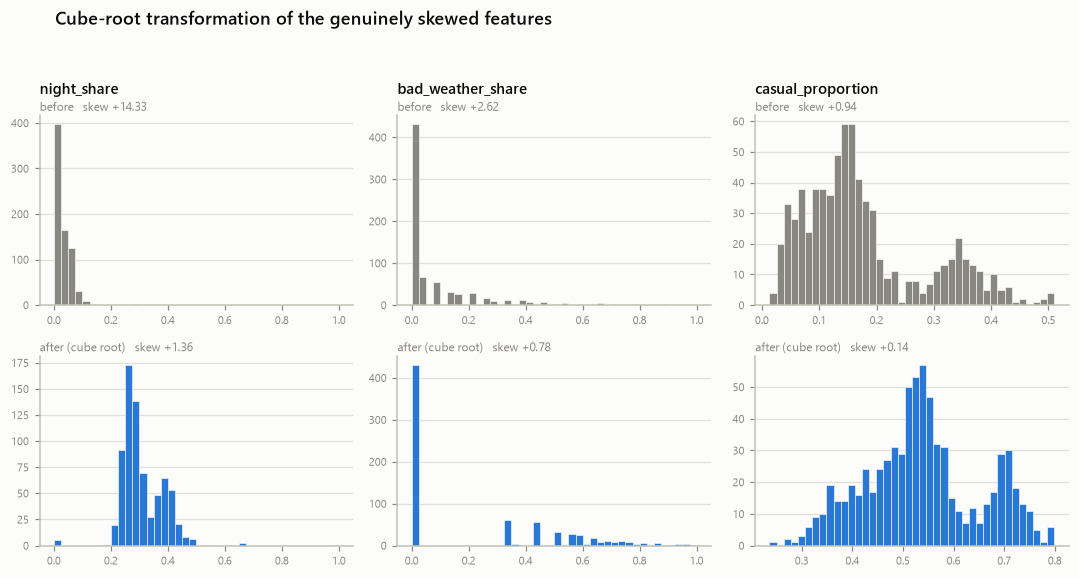

In [39]:
# ---- Figure 6: the effect of the transform --------------------------------
fig, axes = plt.subplots(2, len(TRANSFORMED), figsize=(3.3 * len(TRANSFORMED), 5.2))

for j, col in enumerate(TRANSFORMED):
    axes[0, j].hist(daily[col], bins=40, color=PALETTE["muted"],
                    edgecolor=PALETTE["surface"], linewidth=0.4)
    axes[0, j].set_title(col, fontsize=9.5, pad=14)
    axes[0, j].text(0, 1.01, f"before   skew {daily[col].skew():+.2f}",
                    transform=axes[0, j].transAxes, fontsize=8, color=PALETTE["muted"], va="bottom")

    axes[1, j].hist(features_t[f"{col}_cbrt"], bins=40, color=SERIES[0],
                    edgecolor=PALETTE["surface"], linewidth=0.4)
    axes[1, j].text(0, 1.01, f"after (cube root)   skew {features_t[f'{col}_cbrt'].skew():+.2f}",
                    transform=axes[1, j].transAxes, fontsize=8, color=PALETTE["muted"], va="bottom")

for ax in axes.flat:
    ax.tick_params(labelsize=7.5)
    ax.xaxis.grid(False); ax.yaxis.grid(True)

fig.suptitle("Cube-root transformation of the genuinely skewed features", x=0.055, y=1.0,
             ha="left", fontsize=11.5, fontweight="semibold", color=PALETTE["ink"])
fig.tight_layout(rect=[0, 0, 1, 0.96])
save(fig, "fig06_transformations")
plt.show()

### 1.3.3 Correlation and redundancy analysis

Redundancy is removed in two steps, because the two kinds of redundancy present here call for
different evidence.

**Step 1 — algebraic identities.** Three features are exact linear functions of others *by
construction*, not as an empirical finding. These are demonstrated arithmetically rather than by
correlation, and their removal is not a judgement call: retaining them would make the feature
matrix rank-deficient (their VIF is literally infinite).

**Step 2 — empirical collinearity.** The remaining features are pruned greedily: the most correlated
surviving pair is found, one member is dropped, and the process repeats **until every variance
inflation factor falls below 5**. Using VIF as the stopping criterion means the threshold is not
chosen arbitrarily — pruning stops exactly when no feature is still substantially predictable from
the others.

When a pair must be broken, the member to drop is chosen by a rule declared in advance:
1. keep a specification-**required** feature over an **added** one;
2. if both have the same status, keep the one that is more directly interpretable in a cluster
   profile, using the documented preference order below.

In [40]:
# ---- Step 1: algebraic identities ------------------------------------------
identities = pd.DataFrame([
    ("mean_hourly_rentals",   "total_rentals / 24",
     np.allclose(daily["mean_hourly_rentals"], daily["total_rentals"] / 24)),
    ("offpeak_share",         "1 - morning_peak_share - evening_peak_share",
     np.allclose(daily["offpeak_share"],
                 1 - daily["morning_peak_share"] - daily["evening_peak_share"])),
    ("registered_proportion", "1 - casual_proportion",
     np.allclose(daily["registered_proportion"], 1 - daily["casual_proportion"])),
], columns=["feature", "exactly equals", "identity_holds"])

STRUCTURAL_DROPS = identities["feature"].tolist()
assert identities["identity_holds"].all()
print("These three carry no information of their own and are removed unconditionally:\n")
identities

These three carry no information of their own and are removed unconditionally:



,feature,exactly equals,identity_holds
0,mean_hourly_rentals,total_rentals / 24,True
1,offpeak_share,1 - morning_peak_share - evening_peak_share,True
2,registered_proportion,1 - casual_proportion,True


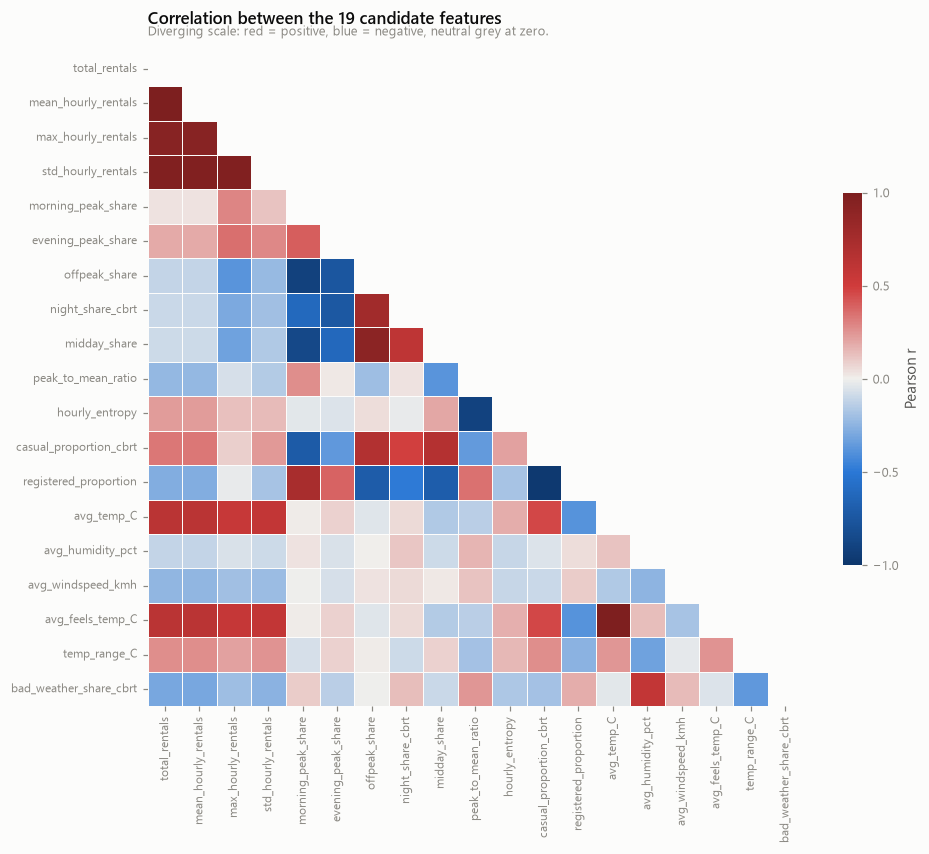

In [41]:
# ---- Correlation matrix of the full candidate set --------------------------
corr_full = features_t.corr()

DIVERGING = mpl.colors.LinearSegmentedColormap.from_list(
    "blue_gray_red", [PALETTE["seq"][-1], SERIES[0], "#f0efec", PALETTE["critical"], "#7d1f1f"])

fig, ax = plt.subplots(figsize=(9.6, 8))
mask = np.triu(np.ones_like(corr_full, dtype=bool))
sns.heatmap(corr_full, mask=mask, cmap=DIVERGING, vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.6, linecolor=PALETTE["surface"], ax=ax,
            cbar_kws={"shrink": 0.55, "label": "Pearson r", "ticks": [-1, -0.5, 0, 0.5, 1]})
ax.tick_params(labelsize=8)
finish(ax, title="Correlation between the 19 candidate features",
       subtitle="Diverging scale: red = positive, blue = negative, neutral grey at zero.",
       ygrid_only=False)
ax.grid(False)
save(fig, "fig07_correlation_full")
plt.show()

In [42]:
# The strongest relationships, ranked.
pairs = (corr_full.where(np.triu(np.ones(corr_full.shape), 1).astype(bool))
                  .stack().rename("r").reset_index())
pairs.columns = ["feature_a", "feature_b", "r"]
pairs["abs_r"] = pairs["r"].abs()
print("Feature pairs with |r| >= 0.85:")
pairs.sort_values("abs_r", ascending=False).head(12).round(4).reset_index(drop=True)

Feature pairs with |r| >= 0.85:


,feature_a,feature_b,r,abs_r
0,total_rentals,mean_hourly_rentals,1.0000,1.0000
1,avg_temp_C,avg_feels_temp_C,0.9917,0.9917
2,total_rentals,std_hourly_rentals,0.9754,0.9754
3,mean_hourly_rentals,std_hourly_rentals,0.9754,0.9754
4,casual_proportion_cbrt,registered_proportion,-0.9725,0.9725
5,max_hourly_rentals,std_hourly_rentals,0.9697,0.9697
6,mean_hourly_rentals,max_hourly_rentals,0.9307,0.9307
7,total_rentals,max_hourly_rentals,0.9307,0.9307
8,morning_peak_share,offpeak_share,-0.9079,0.9079
9,offpeak_share,midday_share,0.9071,0.9071


In [43]:
# ---- Step 2: greedy pruning with a VIF stopping rule -----------------------
from sklearn.preprocessing import StandardScaler


def vif_series(frame):
    """Variance inflation factor per column, computed on standardised data."""
    X = StandardScaler().fit_transform(frame)
    out = {}
    for i, col in enumerate(frame.columns):
        y, A = X[:, i], np.delete(X, i, axis=1)
        coef, *_ = np.linalg.lstsq(A, y, rcond=None)
        r2 = 1 - ((y - A @ coef) ** 2).sum() / (y ** 2).sum()
        out[col] = np.inf if r2 >= 1 - 1e-10 else 1 / (1 - r2)
    return pd.Series(out).sort_values(ascending=False)


# Declared preference order, most interpretable first. Used only to break ties between
# two features of equal specification status.
KEEP_PREFERENCE = [
    "total_rentals", "casual_proportion_cbrt", "morning_peak_share", "evening_peak_share",
    "avg_temp_C", "avg_humidity_pct", "avg_windspeed_kmh",
    "hourly_entropy", "night_share_cbrt", "midday_share", "temp_range_C",
    "bad_weather_share_cbrt", "max_hourly_rentals", "std_hourly_rentals",
    "peak_to_mean_ratio", "avg_feels_temp_C",
]
REQUIRED = set(FEATURE_DOC.loc[FEATURE_DOC.status == "Required", "feature"])
is_required = lambda c: c.replace("_cbrt", "") in REQUIRED

VIF_LIMIT = 5.0
keep = [c for c in features_t.columns if c.replace("_cbrt", "") not in STRUCTURAL_DROPS]
assert set(keep) == set(KEEP_PREFERENCE), set(keep) ^ set(KEEP_PREFERENCE)

prune_log = []
while True:
    v = vif_series(features_t[keep])
    if v.max() < VIF_LIMIT:
        break
    sub = (features_t[keep].corr().abs()
           .where(np.triu(np.ones((len(keep),) * 2), 1).astype(bool)).stack())
    a, b = sub.idxmax()
    if is_required(a) != is_required(b):
        drop, reason = (b, "kept the required feature") if is_required(a) else (a, "kept the required feature")
    else:
        drop = b if KEEP_PREFERENCE.index(a) < KEEP_PREFERENCE.index(b) else a
        reason = "same status; kept the more interpretable"
    prune_log.append({"dropped": drop, "correlated_with": a if drop == b else b,
                      "abs_r": round(sub.max(), 4), "max_VIF_before": round(v.max(), 2),
                      "tie_break": reason})
    keep.remove(drop)

prune_log = pd.DataFrame(prune_log)
print(f"Pruning stopped when every VIF fell below {VIF_LIMIT}. "
      f"{len(prune_log)} features removed.\n")
prune_log

Pruning stopped when every VIF fell below 5.0. 5 features removed.



,dropped,correlated_with,abs_r,max_VIF_before,tie_break
0,avg_feels_temp_C,avg_temp_C,0.9917,121.3100,kept the required feature
1,std_hourly_rentals,total_rentals,0.9754,119.8000,same status; kept the more interpretable
2,max_hourly_rentals,total_rentals,0.9307,26.4400,same status; kept the more interpretable
3,peak_to_mean_ratio,hourly_entropy,0.9052,14.0600,same status; kept the more interpretable
4,midday_share,morning_peak_share,0.8597,11.1900,kept the required feature


In [44]:
SELECTED_FEATURES = keep
final_vif = vif_series(features_t[SELECTED_FEATURES])
max_r = (features_t[SELECTED_FEATURES].corr().abs()
         .where(np.triu(np.ones((len(SELECTED_FEATURES),) * 2), 1).astype(bool)).stack().max())

print(f"Selected features : {len(SELECTED_FEATURES)} of {daily.shape[1]} candidates")
print(f"Maximum |r| among survivors : {max_r:.4f}")
print(f"Maximum VIF among survivors : {final_vif.max():.2f}  (limit {VIF_LIMIT})\n")
final_vif.round(2).rename("VIF").to_frame()

Selected features : 11 of 19 candidates
Maximum |r| among survivors : 0.7370
Maximum VIF among survivors : 4.52  (limit 5.0)



,VIF
casual_proportion_cbrt,4.5200
morning_peak_share,3.7100
night_share_cbrt,3.2600
avg_temp_C,2.7300
evening_peak_share,2.5500
total_rentals,2.0300
bad_weather_share_cbrt,1.9700
avg_humidity_pct,1.9500
temp_range_C,1.3400
avg_windspeed_kmh,1.2900


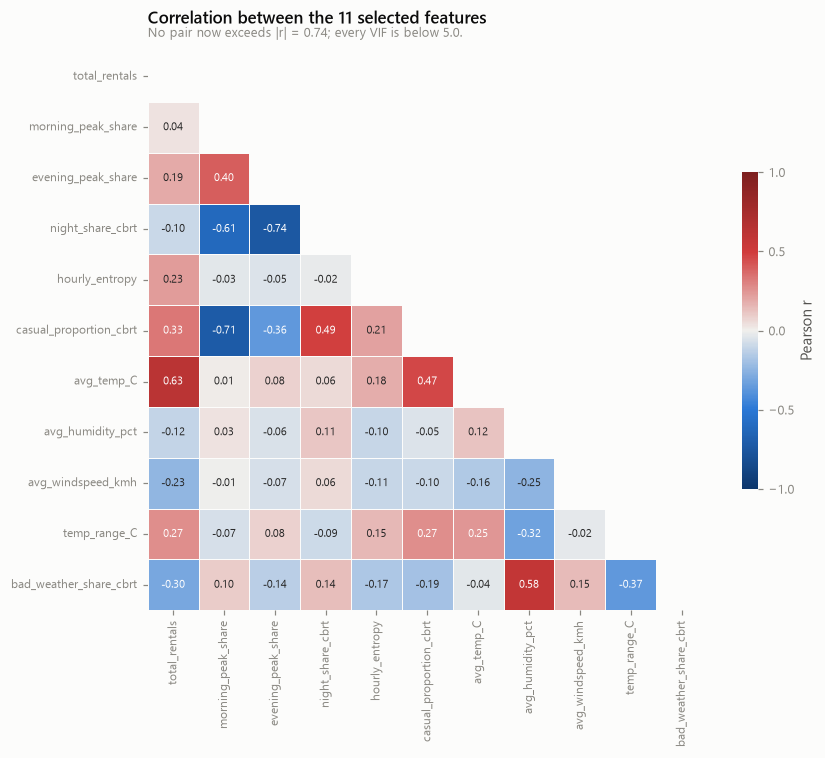

In [45]:
# ---- Correlation structure after pruning -----------------------------------
corr_sel = features_t[SELECTED_FEATURES].corr()

fig, ax = plt.subplots(figsize=(8.2, 6.8))
mask = np.triu(np.ones_like(corr_sel, dtype=bool))
sns.heatmap(corr_sel, mask=mask, cmap=DIVERGING, vmin=-1, vmax=1, center=0, square=True,
            annot=True, fmt=".2f", annot_kws={"size": 7.4},
            linewidths=0.6, linecolor=PALETTE["surface"], ax=ax,
            cbar_kws={"shrink": 0.55, "label": "Pearson r", "ticks": [-1, -0.5, 0, 0.5, 1]})
ax.tick_params(labelsize=8)
finish(ax, title=f"Correlation between the {len(SELECTED_FEATURES)} selected features",
       subtitle=f"No pair now exceeds |r| = {max_r:.2f}; every VIF is below {VIF_LIMIT}.",
       ygrid_only=False)
ax.grid(False)
save(fig, "fig08_correlation_selected")
plt.show()

### 1.3.4 Justification of every removed feature

Eight of the nineteen candidates were removed. None was removed because it produced poor clustering
scores; each removal follows from an identity or from a measured collinearity.

| # | Removed | Reason | Evidence | Information lost |
|---|---|---|---|---|
| 1 | `mean_hourly_rentals` | Algebraic identity: equals `total_rentals / 24` | r = 1.0000 exactly | **None.** A rescaling of a retained feature; identical after standardisation |
| 2 | `registered_proportion` | Algebraic identity: equals `1 − casual_proportion` | r = −1.0000 exactly | **None.** The two encode one degree of freedom |
| 3 | `offpeak_share` | Algebraic identity: equals `1 − morning − evening` | Verified arithmetically | **None.** The three shares span a 2-dimensional simplex |
| 4 | `avg_feels_temp_C` | Collinear with `avg_temp_C` | r = 0.9917 | Negligible. Wind chill is separately represented by `avg_windspeed_kmh` |
| 5 | `std_hourly_rentals` | Collinear with `total_rentals` | r = 0.9754 | Little. Busy days are variable days; profile shape is carried by `hourly_entropy` |
| 6 | `max_hourly_rentals` | Collinear with `total_rentals` | r = 0.9307 | Little. Recoverable as `total × concentration` |
| 7 | `peak_to_mean_ratio` | Collinear with `hourly_entropy` | r = 0.9052 | Little. Both measure concentration; entropy is bounded, uses all 24 hours, and is far less sensitive to a single extreme hour |
| 8 | `midday_share` | Collinear with `morning_peak_share` | r = 0.8597 | Some. Days with no morning commute are almost exactly the days with a large midday plateau, so the pair is close to one axis |

**On removals 5 and 6 — a caveat stated honestly.** `total_rentals`, `std_hourly_rentals` and
`max_hourly_rentals` are all specification-required, and all three describe a single underlying
"how busy was the day" dimension. Which one survives is close to arbitrary on statistical grounds:
`total_rentals` and `std_hourly_rentals` differ by only 0.001 in mean absolute correlation against
the rest of the set. `total_rentals` is retained because Part 2.1 requires centroids reported on the
original scale and Part 4 requires interpretable profiles — "4,504 rentals per day" is a
meaningful cluster descriptor where "a standard deviation of 150" is not. The check below confirms
that this preference has no material effect on the geometry the algorithms will see.

In [46]:
# ---- Robustness check: does the total-vs-std choice actually matter? -------
from scipy.spatial.distance import pdist
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

alt = [c for c in SELECTED_FEATURES if c != "total_rentals"] + ["std_hourly_rentals"]
Xa = StandardScaler().fit_transform(features_t[SELECTED_FEATURES])
Xb = StandardScaler().fit_transform(features_t[alt])

d_corr = stats.pearsonr(pdist(Xa), pdist(Xb))[0]
ka = KMeans(4, n_init=20, random_state=RANDOM_STATE).fit_predict(Xa)
kb = KMeans(4, n_init=20, random_state=RANDOM_STATE).fit_predict(Xb)

print("Selected set vs the alternative that keeps std_hourly_rentals instead:")
print(f"  correlation between the two pairwise-distance matrices : {d_corr:.5f}  "
      f"({len(pdist(Xa)):,} pairs)")
print(f"  agreement of the two k=4 partitions (adjusted Rand)     : "
      f"{adjusted_rand_score(ka, kb):.4f}")
print("\nThe two choices describe essentially the same geometry, so the preference for the\n"
      "more interpretable feature carries no analytical cost.")

Selected set vs the alternative that keeps std_hourly_rentals instead:
  correlation between the two pairwise-distance matrices : 0.99867  (266,815 pairs)
  agreement of the two k=4 partitions (adjusted Rand)     : 0.9542

The two choices describe essentially the same geometry, so the preference for the
more interpretable feature carries no analytical cost.


### 1.3.5 Feature scaling

The selected features are standardised to zero mean and unit variance
(`StandardScaler`, i.e. `z = (x − μ) / σ`).

This is not optional here. The retained features are expressed in units that differ by four orders
of magnitude — `total_rentals` spans 22 to 8,714 while `morning_peak_share` spans 0 to 0.38.
Euclidean distance is a sum of squared coordinate differences, so on raw values the daily total
would contribute virtually the whole distance and every share and weather feature would be
invisible. K-means, AGNES and DBSCAN are all distance-based and would each be driven almost
entirely by one feature.

Standardisation is fitted on all 731 days. The **unscaled** `daily` table is deliberately kept
intact so that §2.1 can invert the transformation to report centroids in original units and Part 4
can profile clusters in physical quantities.

In [47]:
scaler = StandardScaler().fit(features_t[SELECTED_FEATURES])
X = scaler.transform(features_t[SELECTED_FEATURES])
X_df = pd.DataFrame(X, index=features_t.index, columns=SELECTED_FEATURES)

scaling_checks = pd.DataFrame([
    ("Shape is (731, %d)" % len(SELECTED_FEATURES), X.shape == (731, len(SELECTED_FEATURES))),
    ("Every column has mean 0",      bool(np.allclose(X.mean(axis=0), 0, atol=1e-12))),
    ("Every column has unit variance", bool(np.allclose(X.std(axis=0), 1, atol=1e-12))),
    ("No missing or infinite values", bool(np.isfinite(X).all())),
    ("Matrix is full rank",           np.linalg.matrix_rank(X) == X.shape[1]),
    ("All 731 days retained",         X.shape[0] == 731),
], columns=["verification", "passed"])
scaling_checks["result"] = np.where(scaling_checks["passed"], "PASS", "FAIL")
assert scaling_checks["passed"].all()

print(f"Clustering matrix X : {X.shape[0]} days x {X.shape[1]} standardised features")
print(f"Rank {np.linalg.matrix_rank(X)} of {X.shape[1]} -- no residual linear dependency.\n")
scaling_checks[["verification", "result"]]

Clustering matrix X : 731 days x 11 standardised features
Rank 11 of 11 -- no residual linear dependency.



,verification,result
0,"Shape is (731, 11)",PASS
1,Every column has mean 0,PASS
2,Every column has unit variance,PASS
3,No missing or infinite values,PASS
4,Matrix is full rank,PASS
5,All 731 days retained,PASS


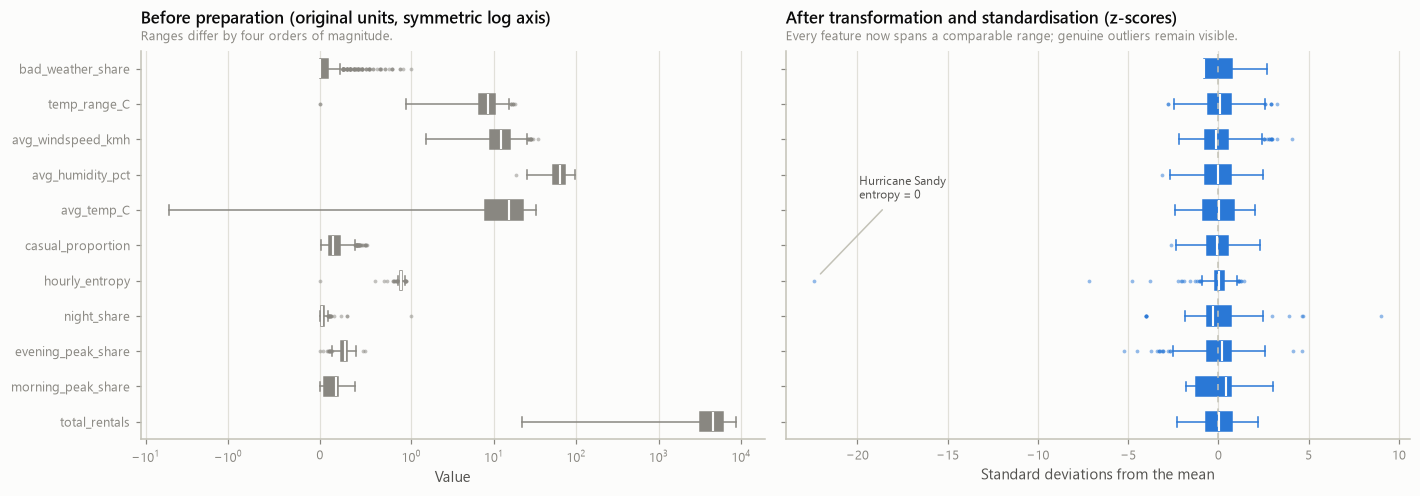

In [48]:
# ---- Figure 9: the scaling problem, and its fix ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

axes[0].boxplot([daily[c.replace("_cbrt", "")] for c in SELECTED_FEATURES], orientation="horizontal",
                widths=0.55, patch_artist=True,
                boxprops=dict(facecolor=PALETTE["muted"], color=PALETTE["muted"]),
                medianprops=dict(color=PALETTE["surface"], linewidth=1.4),
                whiskerprops=dict(color=PALETTE["muted"]),
                capprops=dict(color=PALETTE["muted"]),
                flierprops=dict(marker="o", markersize=2.5, markerfacecolor=PALETTE["muted"],
                                markeredgecolor="none", alpha=0.5))
axes[0].set_xscale("symlog", linthresh=1)
axes[0].set_yticks(range(1, len(SELECTED_FEATURES) + 1))
axes[0].set_yticklabels([c.replace("_cbrt", "") for c in SELECTED_FEATURES], fontsize=8.5)
finish(axes[0], title="Before preparation (original units, symmetric log axis)",
       subtitle="Ranges differ by four orders of magnitude.", xlabel="Value", ygrid_only=False)
axes[0].yaxis.grid(False); axes[0].xaxis.grid(True)

axes[1].boxplot([X_df[c] for c in SELECTED_FEATURES], orientation="horizontal", widths=0.55, patch_artist=True,
                boxprops=dict(facecolor=SERIES[0], color=SERIES[0]),
                medianprops=dict(color=PALETTE["surface"], linewidth=1.4),
                whiskerprops=dict(color=SERIES[0]), capprops=dict(color=SERIES[0]),
                flierprops=dict(marker="o", markersize=2.5, markerfacecolor=SERIES[0],
                                markeredgecolor="none", alpha=0.5))
axes[1].set_yticks(range(1, len(SELECTED_FEATURES) + 1))
axes[1].set_yticklabels([""] * len(SELECTED_FEATURES))
axes[1].axvline(0, color=PALETTE["axis"], lw=1, ls=(0, (4, 4)))

# Name the single most extreme point rather than clipping the axis to hide it.
_row = SELECTED_FEATURES.index("hourly_entropy") + 1
_z   = X_df["hourly_entropy"].min()
axes[1].annotate("Hurricane Sandy\nentropy = 0", xy=(_z, _row), xytext=(_z + 2.5, _row + 2.6),
                 fontsize=8, color=PALETTE["ink2"], ha="left", va="center",
                 arrowprops=dict(arrowstyle="-", color=PALETTE["axis"], lw=1,
                                 shrinkA=4, shrinkB=6))

finish(axes[1], title="After transformation and standardisation (z-scores)",
       subtitle="Every feature now spans a comparable range; genuine outliers remain visible.",
       xlabel="Standard deviations from the mean", ygrid_only=False)
axes[1].yaxis.grid(False); axes[1].xaxis.grid(True)

fig.tight_layout()
save(fig, "fig09_scaling")
plt.show()

> **Reading.** The left panel needs a logarithmic axis simply to render all eleven features in one
> frame, which is the argument for scaling in a single image: on a linear scale, ten of the eleven
> boxes would collapse onto the zero line beside `total_rentals`. After standardisation every
> feature occupies a comparable range, so the clustering geometry reflects all eleven dimensions
> rather than one.
>
> The remaining outlying points on the right are not errors — they are the storm days and other
> genuinely unusual days, still visible and still separable, exactly as intended.

### 1.3.6 Summary of §1.3

| Requirement | What was done | Result |
|---|---|---|
| Examine feature distributions | Skewness, kurtosis and histograms for all 19 candidates, decomposed by data-quality flag (Figs. 4–5) | 12 symmetric, 2 storm-driven, 5 genuinely skewed |
| Identify highly skewed features and transform | Cube root where storm-excluded \|skew\| > 0.75 *and* the transform reduces it (Fig. 6) | 3 transformed; 2 rejected as left-skewed; storm-driven skew deliberately preserved |
| Investigate correlated / redundant features | 3 algebraic identities removed, then greedy \|r\| pruning to a VIF < 5 stopping rule (Figs. 7–8) | 8 removed, 11 retained; max \|r\| 0.74, max VIF 4.5 |
| Standardise the selected features | `StandardScaler` fitted on all 731 days (Fig. 9) | 731 × 11 matrix, mean 0, unit variance, full rank |
| Justify removed features | Identity or measured collinearity given for each; robustness of the one judgement call demonstrated | See §1.3.4 |

**The eleven features carried into Part 2**, still balanced across the four groups so that no single
aspect of mobility dominates the distance metric:

| Group | Features |
|---|---|
| Volume (1) | `total_rentals` |
| Temporal shape (4) | `morning_peak_share`, `evening_peak_share`, `night_share_cbrt`, `hourly_entropy` |
| User mix (1) | `casual_proportion_cbrt` |
| Weather (5) | `avg_temp_C`, `avg_humidity_pct`, `avg_windspeed_kmh`, `temp_range_C`, `bad_weather_share_cbrt` |

In [49]:
print(f"X       : {X.shape[0]} x {X.shape[1]}   standardised clustering matrix")
print(f"daily   : {daily.shape[0]} x {daily.shape[1]}   original units, for interpretation")
print(f"context : {context.shape[0]} x {context.shape[1]}   labels, for validation\n")

summary_13 = pd.DataFrame({
    "transformed": [c in TRANSFORMED_NAMES for c in SELECTED_FEATURES],
    "group": [FEATURE_DOC.set_index("feature")["group"][c.replace("_cbrt", "")]
              for c in SELECTED_FEATURES],
    "status": [FEATURE_DOC.set_index("feature")["status"][c.replace("_cbrt", "")]
               for c in SELECTED_FEATURES],
    "skew_final": features_t[SELECTED_FEATURES].skew().to_numpy(),
    "VIF": final_vif.reindex(SELECTED_FEATURES).to_numpy(),
}, index=SELECTED_FEATURES)
summary_13.round(3)

X       : 731 x 11   standardised clustering matrix
daily   : 731 x 19   original units, for interpretation
context : 731 x 15   labels, for validation



,transformed,group,status,skew_final,VIF
total_rentals,False,Volume,Required,-0.0470,2.0340
morning_peak_share,False,Shape,Required,-0.3460,3.7140
evening_peak_share,False,Shape,Required,-0.7410,2.5460
night_share_cbrt,True,Shape,Added,1.3630,3.2550
hourly_entropy,False,Shape,Added,-16.1570,1.1260
casual_proportion_cbrt,True,User mix,Required,0.1350,4.5230
avg_temp_C,False,Weather,Required,-0.0550,2.7340
avg_humidity_pct,False,Weather,Required,0.0290,1.9500
avg_windspeed_kmh,False,Weather,Required,0.6770,1.2870
temp_range_C,False,Weather,Added,0.1320,1.3380


---
*Section 1.4 continues with exploratory visualisation of the prepared data, including PCA.*